In [1]:
1+0

1

### Description

March 27, 2025

I will use this notebook to make plots that will be used for making my request to access the near sideband.

Plan:

With MC, apply all cuts EXCEPT cuts I flip for s.b. and track length cut. Show that with this choice of near s.b., signal in sideband is small, even when scaled to best model benchmark. Include the CV weights and the uncertainties on signal and background MC.


Need: 

CV weights and uncertainties on both signal and bg MC. I have so many samples now, so for this exercise I should strategically choose a subset of the samples to do the study on (less processing time to get full uncertainties).

Note: I have already processed these for the nu background, and they are stored at /exp/icarus/data/users/jdyer/muon_datamc/samples_240909/allMC_ie_no_restriction_to_sideband_wConcreteFix_240909/

- the mc_coh file was made from just one of the cohlike samples (cohlike_nu_file = gray_df_dir + "F-CohLike_nom_evt.df").
- the mc_incoh never explicitly had the cohlike events masked out of it by me. But that was taken care of within the make_dataset() function. 

Here, I need to also process the CV weights and uncertainties for some signal benchmarks.



In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import pickle
import h5py
import math
import re
from IPython.display import display

from util import *
import var
import cut
import data
import hist

import importlib

import pid
from pyanalib import panda_helpers
import os
import multiprocessing

from unc_funcs import *
from unc_samples import *
#from unc_MCdata_overhead import *
from unc_cuts import *

#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

#import subprocess

## Samples I'll use here (subset of all the samples)
(This content would normally be in unc_MCdata_overhead.py, but since I'm doing just a subset of the samples for this exercise, I'm going to contain it to this notebook.)

- Nominal nu sample: nu_file
- Cohlike nus: cohlike_nu_file
- Cohlike detector variations: cohlike_nu_detVar_files

In [3]:
onbeamR1_pot = 4.651603646822754e+19
print('onbeamR1_pot: ', onbeamR1_pot)
onbeamR1_livetime = 9712335.74

onbeamR2_pot = 1.9447555727369336e+20
print('onbeamR2_pot: ', onbeamR2_pot)
onbeamR2_livetime = 40955958.70833331

onbeam_pot = onbeamR1_pot + onbeamR2_pot
print('Combined onbeam POT: ', onbeam_pot)
GOAL_POT = onbeam_pot

print(GOAL_POT)

onbeamR1_pot:  4.651603646822754e+19
onbeamR2_pot:  1.9447555727369336e+20
Combined onbeam POT:  2.409915937419209e+20
2.409915937419209e+20


In [26]:
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2503/'
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/' # These have corrected CV weights for the flux updates I included over the summer.
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/' # The systematics included in these are calculated with the work that is described in slides titled 211114_asymmetricFluxUnc.pptx
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/' # same as above, but referring to parent particle pdg for the flux weights for the bsm samples.



### June 16, 2025

In [5]:
import uproot
def histdf(h):
    values = h.values()
    bins = h.axis().edges()
    idx = pd.IntervalIndex.from_breaks(bins)
    return pd.Series(values, idx, name=None)
           
def getallpdg_histdf(d, prefix, pdgs=None):
    if pdgs is None:
        pdgs = {
            "numu": 14,
            "numubar": -14,
            "nue": 12,
            "nuebar": -12 
        }

    hs = []
    for pdgname, pdgcode in pdgs.items():
        h = histdf(d[prefix + pdgname])
        h.index = pd.MultiIndex.from_product([[pdgcode], h.index], names=["pdg", "E"])
        hs.append(h)
    return pd.concat(hs)
FLUX_CORRECTION_FILE = "/pnfs/icarus/persistent/users/faabdalr/2025-04-08_out_450.37_7991.98_79512.66.root"
FLUX_CORRECTION_HIST_PREFIX = "g4numi_reweight_v02_-->v03_02.hnom_"
pdgs = {
    "numu_weights": 14,
    "numubar_weights": -14,
    "nue_weights": 12,
    "nuebar_weights": -12, 
    # or, use parent PDG to reweight:
    "numu_kpm_weights": 321, 
    "numubar_kpm_weights": -321, 
    "nue_k0l_weights": 130
    }

fluxcorr = getallpdg_histdf(uproot.open(FLUX_CORRECTION_FILE), FLUX_CORRECTION_HIST_PREFIX, pdgs)


## Stuff to Run Once:

In [ ]:
# Investigate: What happens with cosmics in the act of masking cohlike events out of 
#              the nominal neutrino sample?

nomnu_evt = data.mc_dataset(nu_file, "evt", mcnukey="mcnuwgt")#, mccut=mccut)


In [ ]:
# Q: How many slices classified as cosmic in the cohlike sample are considered cohlike by the "is_coh_like" function?


In [ ]:
cats = make_categories(nomnu_evt, detailed_nu='int_type')
for c in cats:
    print(c.name, nomnu_evt[c].shape, sep=': ')

In [ ]:
# Notes:
# - maybe pile up. Run the same check, but for events instead of slices.
# - something to fix: 
#     - remove EVENTS (not slices) that have any cohlike slice in them from nominal sample.
#.    - OR, only keep the cohlike neutrinos in the cohlike sample and keep my fix the same (ie remove cohlike neutrinos/slices forom nominal)
# 

In [ ]:
mccoh_evt = pd.read_hdf(filedir + "mc_coh", "evt")


In [ ]:
print(mccoh_evt.shape)
print(mccoh_evt[is_coh_like_JD(mccoh_evt)].shape)
# TAKEAWAY: not every reconstructed slice in the cohlike sample is considered cohlike by the cohlike-identifier function

In [ ]:
coh_cats = make_categories(mccoh_evt, detailed_nu='int_type')
for c in coh_cats:
    print(c.name)
    print('\t shape of this category: ', mccoh_evt[c].shape)
    print('\t shape of this category that is considered cohlike: ', mccoh_evt[c][is_coh_like_JD(mccoh_evt[c])].shape)
    print(' ')

In [ ]:
coh_cosmics = mccoh_evt[coh_cats[-1]]
print(coh_cosmsics.shape)

In [ ]:
evt_test1 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt")
evt_test2 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt", mccut=is_coh_like)
evt_test3 = data.mc_dataset(cohlike_nu_file, "evt", mcnukey="mcnuwgt", mccut=~is_coh_like)



In [ ]:
print('All cohlike: ', evt_test1.df.shape)
print('Cohlike from cohlike: ', evt_test2.df.shape)
print('Cohlike_JD from cohlike: ', evt_test1.df[is_coh_like_JD(evt_test1.df)].shape)
print('')
print('Not-cohlike from cohlike: ', evt_test3.df.shape)
print('Not-Cohlike_JD from cohlike: ', evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape)
print('')

print(evt_test2.df.shape[0] + evt_test3.df.shape[0])
print('')
print(evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape[0] + evt_test1.df[is_coh_like_JD(evt_test1.df)].shape[0])

In [ ]:
# Takeaway number 1: is_coh_like and ~is_coh_like are not orthogonal (which is effed.)
# Takeaway number 2: is_coh_like_JD and ~is_coh_like_JD ARE orthogonal (which is fair and just)
# Takeaway number 3: I should use is_coh_like_JD instead of is_coh_like when I make my dataframes.



In [8]:
filedir = savedir
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt")
mccoh_evt = pd.read_hdf(filedir + "mc_coh", "evt")


FileNotFoundError: File /exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/mc_incoh does not exist

In [15]:
print('All cohlike: ', mccoh_evt.shape)
#print('Cohlike from cohlike: ', evt_test2.df.shape)
print('Cohlike_JD from cohlike: ', mccoh_evt[is_coh_like_JD(mccoh_evt)].shape)
print('Not-Cohlike_JD from Cohlike: ', mccoh_evt[~is_coh_like_JD(mccoh_evt)].shape)
print('')
print('All Not-cohlike: ', mc_incoh_evt.shape)
print('Cohlike from Not-cohlike: ', mc_incoh_evt[is_coh_like_JD(mc_incoh_evt)].shape)
print('Not-Cohlike_JD from All Not-cohlike: ', mc_incoh_evt[~is_coh_like_JD(mc_incoh_evt)].shape)
print('')

#print(evt_test2.df.shape[0] + evt_test3.df.shape[0])
#print('')
#print(evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape[0] + evt_test1.df[is_coh_like_JD(evt_test1.df)].shape[0])

All cohlike:  (103855, 788)
Cohlike_JD from cohlike:  (103855, 788)
Not-Cohlike_JD from Cohlike:  (0, 788)

All Not-cohlike:  (220197, 788)
Cohlike from Not-cohlike:  (0, 788)
Not-Cohlike_JD from All Not-cohlike:  (220197, 788)



In [ ]:
# end of study.

In [27]:
nmu = var.DF.iscc & ((var.DF.pdg == 14) | (var.DF.pdg == -14))
npi = var.DF.npi
ns = var.DF.nsm + var.DF.nsp
is_coh_like = (nmu + npi + ns >= 2) & (var.DF.max_proton_ke < 0.05)

def resave_datasets(df_names, df_list, output):
    with pd.HDFStore(output) as hdf:
        for k,df in zip(df_names, df_list):
            try:
                hdf.put(key=k, value=df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % (k, str(e)))
                
                

In [28]:
# 4/3/25: make a function to do this so I don't have to copy/paste this block for every sample.

def JD_make_cvDF_w_cvWgt_and_systs(file, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False,
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    print('file: ', file)
    if mc:
        evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt", isscalar=bsm)#, mccut=mccut)
        evt_df = evt.df
        if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
        evt_df["mc"] = mc
        evt_df["mc_incoh"] = mc_incoh
        evt_df["mccoh"] = mccoh
        evt_df["bsm"] = bsm
        ## WIP (and may not follow through)
        #if hps=True:
        #    mchdf = pd.read_hdf(file, key="mch")
        #    evt_df["mass"] = int(round(mchdf.iloc[(0)].M*1000.))
        #    evt_df["theta"] = float(mchdf.iloc[(0)].C1)
        #    evt_df["sample"] = "$M_S$ = %a, $\\theta_S$ = %a" % (int(round(mchdf.iloc[(0)].M*1000.)), float(mchdf.iloc[(0)].C1))
        #else:
        #    evt_df["mass"] = -1
        #    evt_df["theta"] = -1
        #    evt_df["sample"] = 'na'
        evt_df["hps"] = hps
        evt_df["alp"] = alp
        evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)#, newcol_name=None, newcol_val=None)
    # resave dataset with lightened evt dataframe:
    df_names = ['evt', 'hdr', 'mch', 'mcnu']
    resave_datasets(df_names, 
                    [evt_df,
                     pd.read_hdf(file, "hdr"),
                     pd.read_hdf(file, "mch"),
                     pd.read_hdf(file, "mcnu")
                    ], 
                    savedir+label
                   )
    del evt
    del evt_df


In [29]:
mcdf = pd.read_hdf(nu_file, key="mcnuwgt")


In [30]:
beam_systematics = [ # the +1 sigma variations.
    "Beam_shift_x",
    "Beam_shift_y",
    "Beam_spot",
    "Horn1_x",
    "Horn1_y",
    "Horn2_x",
    "Horn2_y",
    "Horn_current",
    "Horn_water",
    "Target_z"
] + ["pca%i" % i for i in range(20)]

counter_startswith = 0
count_has = 0
for s in beam_systematics:
    if mcdf[s].columns[0][0].startswith("ps"):
        counter_startswith=+1
        print('sw: ', mcdf[s].columns[0][0])
    if 'ps' in mcdf[s].columns[0][0]:
        count_has=+1
        print('has: ', mcdf[s].columns[0][0])
print(counter_startswith)
print(count_has)


has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
has:  actual_ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
sw:  ps1
has:  ps1
1
1


In [31]:
print(savedir)

/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/


In [8]:
# CV signal samples: (fast cell)

# Nus:
JD_make_cvDF_w_cvWgt_and_systs(nu_file, 'mc_incoh', mc=True, mccut=is_NOT_coh_like_JD, mc_incoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_1, 'mc_coh_1', mc=True, mccut=is_coh_like_JD, mccoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_2, 'mc_coh_2', mc=True, mccut=is_coh_like_JD, mccoh=True)

# HPS:
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M220_nom_evt.df", 'mS_220', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M260_nom_evt.df", 'mS_260', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M300_nom_evt.df", 'mS_300', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M340_nom_evt.df", 'mS_340', mc=True, bsm=True, hps=True)

JD_make_cvDF_w_cvWgt_and_systs(higgs_files[0], 'mS_220', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[1], 'mS_240', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[2], 'mS_260', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[3], 'mS_280', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[4], 'mS_300', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[5], 'mS_320', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[6], 'mS_340', mc=True, bsm=True, hps=True)

# ALPs:
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma300_faE6.df", 'ma_300', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma350_faE6.df", 'ma_350', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma400_faE6.df", 'ma_400', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma450_faE6.df", 'ma_450', mc=True, bsm=True, alp=True)

JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[0], 'ma_300', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[2], 'ma_350', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[3], 'ma_400', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[4], 'ma_450', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[5], 'ma_500', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[6], 'ma_540', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[7], 'ma_600', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[8], 'ma_650', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[9], 'ma_700', mc=True, bsm=True, alp=True)



file:  /exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike-F-1.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:54: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

Beam_shift_x
Beam_shift_y
Beam_spot
Horn1_x
Horn1_y
Horn2_x
Horn2_y
Horn_current
Horn_water
Target_z
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
Cant find systematic called 'reinteractions_piminus_Geant4' in df. Fix this!!
reinteractions_piplus_Geant4
Cant find systematic called 'reinteractions_piplus_Geant4' in df. Fix this!!
reinteractions_proton_Geant4
Cant find systematic called 'reinteractions_proton_Geant4' in df. Fix this!!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:151: PerformanceWarning: D

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_852357/2654351296.py:10: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key=k, value=df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: Natura

In [6]:
print(savedir)

/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/


In [28]:
def combine_two_df_of_same_sample(f1, f2):
    # Note 12/3/25: Due to their being two dfs per detector variation, since there were too many CAFs to run a single makedf command, 
    #               I need to make sure they don't have any redundant indices. I think that the way I am doing it here will ruin the 
    #               ability to track down the correct "ntuple" (i.e. CAF file) for events from evt_2, in case I need to investigate stuff
    #               upstream. If I end up needing to, I'll need to backwards-logic it out based on how I handle the indices here, and
    #               using the original list of caf files used to make the dataframe.
    x = data.mc_dataset(f1, "evt", mcnukey="mcnuwgt")
    evt_1 = x.df
    evt_1['livetime'] = x.livetime
    evt_1['POT'] = x.POT
    print(evt_1.POT.unique())
    
    y = data.mc_dataset(f2, "evt", mcnukey="mcnuwgt")
    evt_2 = y.df
    evt_2['livetime'] = y.livetime
    evt_2['POT'] = y.POT
    print(evt_2.POT.unique())
    
    hdr_1 = pd.read_hdf(f1, "hdr")
    mch_1 = pd.read_hdf(f1, "mch")
    mcnu_1 = pd.read_hdf(f1, "mcnu")
    df1list = [evt_1, hdr_1, mch_1, mcnu_1]
    
    hdr_2 = pd.read_hdf(f2, "hdr")
    mch_2 = pd.read_hdf(f2, "mch")
    mcnu_2 = pd.read_hdf(f2, "mcnu")
    
    level_to_modify = '__ntuple' # or 1 for integer position
    number_to_add = max([df.index.levels[0].max() for df in df1list]) # just in case the number differs across the dataframes.
    dfs = []
    for d, df2 in enumerate([evt_2, hdr_2, mch_2, mcnu_2]):
        modified_level_values = df2.index.get_level_values(level_to_modify).map(lambda x: str(int(x) + number_to_add))
        new_arrays = [] # Create a list of arrays for the new MultiIndex
        for i, name in enumerate(df2.index.names):
            if i == 0: 
                print(d, ', ', name)
            if name==level_to_modify:
                new_arrays.append(modified_level_values)
            else:
                new_arrays.append(df2.index.get_level_values(name))
        new_multi_index = pd.MultiIndex.from_arrays(new_arrays, names=df2.index.names)
        df2.index = new_multi_index # Assign the new MultiIndex to the DataFrame
                
        common_indices = df1list[d].index.intersection(df2.index)
        assert len(common_indices)==0
        dfs.append(pd.concat([df1list[d], df2]))
    del x 
    del y
    return dfs 
        
        
    

In [30]:
combined_dfs = combine_two_df_of_same_sample(cohlike_nu_detVar_files[0], cohlike_nu_detVar_files[1])

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:54: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


...

Beam_shift_x
Beam_shift_y
Beam_spot
Horn1_x
Horn1_y
Horn2_x
Horn2_y
Horn_current
Horn_water
Target_z
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:151: PerformanceWarning: D

[1.8516344e+21]
0 ,  __ntuple
1 ,  __ntuple
2 ,  __ntuple
3 ,  __ntuple


In [40]:
test = combined_dfs[0]
print(test.POT.unique())


[2.9708161e+21 1.8516344e+21]


In [9]:
print(evt_1.index.names)
print(evt_1.index.levels[0].max())
hdr_1 = pd.read_hdf(updated_df_dir + "cohlike_ind1bin0-1.df", "hdr")
print(hdr_1.index.names)
print(hdr_1.index.levels[0].max())
mch_1 = pd.read_hdf(updated_df_dir + "cohlike_ind1bin0-1.df", "mch")
print(mch_1.index.names)
print(mch_1.index.levels[0].max())
mcnu_1 = pd.read_hdf(updated_df_dir + "cohlike_ind1bin0-1.df", "mcnu")
print(mcnu_1.index.levels[0].max())
print(mcnu_1.index.names)


['__ntuple', 'entry', 'rec.slc..index']
4997
['__ntuple', 'entry']
4997
['__ntuple', 'entry', 'rec.mc.prtl..index']
nan
4997
['__ntuple', 'entry', 'rec.mc.nu..index']


In [25]:
# Signal Sample Detector Variations:

def JD_make_dvDF_w_cvWgt_and_systs(detVar_files, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False, 
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    label_counter = 0
    for i, file in enumerate(detVar_files):
        if (mccoh) & (i%2 != 0): 
            continue
        print(file, detVar_labels[label_counter], sep=' ')
        print(file)
        print(detVar_files[i+1])
        if mc:
            if bsm:
                evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt", isscalar=bsm)#, mccut=mccut)
                evt_df = evt.df
                evt_df['livetime'] = evt.livetime
                evt_df['POT'] = evt.POT #print('\n')
                hdr_df = pd.read_hdf(file, "hdr")
                mch_df = pd.read_hdf(file, "mch")
                mcnu_df = pd.read_hdf(file, "mcnu")
            if mccoh:
                all_types_dfs = combine_two_df_of_same_sample(file, detVar_files[i+1])
                evt_df = all_types_dfs[0]
                hdr_df = all_types_dfs[1]
                mch_df = all_types_dfs[2]
                mcnu_df = all_types_dfs[3]
                
            if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
            evt_df["mc"] = mc
            evt_df["mc_incoh"] = mc_incoh
            evt_df["mccoh"] = mccoh
            evt_df["bsm"] = bsm
            evt_df["hps"] = hps
            evt_df["alp"] = alp
            evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
        #
        #print('systFile: ', file)
        #print('livetime: ', evt.livetime)
        #print('POT: ', evt.POT)
        evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events):
        when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end)
        evt_df = evt_df[when_uncontained] # Require exiting
        evt_df = add_calculated_evtdf_cols(evt_df)
    
        # resave:
        output = savedir + label + '_' + detVar_labels[label_counter].replace(' ', '_')
        label_counter = label_counter + 1
        try: 
            subprocess.run(['rm', output])
        except:
            print("Did not delete a pre-existing file.")
        with pd.HDFStore(output) as hdf:
            # save the evt key to the dataset:
            try:
                hdf.put(key='evt', value=evt_df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('evt', str(e)))
            # save the hdr key to the dataset:    
            try:
                hdf.put(key='hdr', value=hdr_df, format="fixed")
                hdf.put(key='mch', value=mch_df, format="fixed")
                hdf.put(key='mcnu', value=mcnu_df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('hdr', str(e)))



In [12]:
for l in detVar_labels:
    print(l)
for f in cohlike_nu_detVar_files:
    print(f)

Middle Ind. Opacity
Noise 1.2x
Space Charge 2x
Ind0 Nom
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind0nom-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind0nom-2.df


In [18]:
%%time
# Nus:
JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True)


/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df Middle Ind. Opacity
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:54: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:31: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

0 ,  __ntuple
1 ,  __ntuple
2 ,  __ntuple
3 ,  __ntuple
recognized mccut
shape of evt_df before applying mccut:  (245145, 799)
shape of evt_df after applying mccut:  (184877, 799)


/tmp/ipykernel_614292/665632492.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc"] = mc
/tmp/ipykernel_614292/665632492.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc_incoh"] = mc_incoh
/tmp/ipykernel_614292/665632492.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

Did not delete a pre-existing file.


/tmp/ipykernel_614292/665632492.py:83: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis1_level0] [items->None]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_614292/665632492.py:83: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_conta

CPU times: user 10min 17s, sys: 4min 26s, total: 14min 44s
Wall time: 12min 45s


In [ ]:
# Signal Detector Variations:

# Nus:
JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True)

# HPS
JD_make_dvDF_w_cvWgt_and_systs(higgs_220_detVar_files, 'mS_220', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_260_detVar_files, 'mS_260', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_300_detVar_files, 'mS_300', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_340_detVar_files, 'mS_340', bsm=True, hps=True)

# ALPs



/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin0_evt.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


beam_div
beam_shift_x
beam_spot
horn1_x
horn1_y
horn_current_plus
water_layer
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


In [10]:
JD_make_dvDF_w_cvWgt_and_systs(alp_300_detVar_files, 'ma_300', bsm=True, alp=True)


/exp/icarus/data/users/jdyer/dimuon-data/2504_AlpDetectorVariations/Alp_M300_ind1bin0.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_

Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:131: PerformanceWarning: D

Did not delete a pre-existing file.


/tmp/ipykernel_458135/3973249541.py:40: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.mc.prtl..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py

## Every other time, start here


In [5]:

filedir = savedir
print(savedir)


/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/


### Load CV dataframes: 

In [6]:
## mc_incoh
#print(h5py.File(filedir + "mc_incoh", 'r').keys())
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt")
mc_incoh_evt["scale"] = GOAL_POT/mc_incoh_evt.POT
mc_incoh_hdr = pd.read_hdf(filedir + "mc_incoh", "hdr")
#mc_incoh_evt = simpler_add_hdr_info(mc_incoh_evt, mc_incoh_hdr)

## mc_coh

mccoh_evt_1 = pd.read_hdf(filedir + "mc_coh_1", "evt")
mccoh_hdr_1 = pd.read_hdf(filedir + "mc_coh_1", "hdr")

mccoh_evt_2 = pd.read_hdf(filedir + "mc_coh_2", "evt")
mccoh_hdr_2 = pd.read_hdf(filedir + "mc_coh_2", "hdr")

total_cohlike_POT = mccoh_evt_1.POT.unique()[0] + mccoh_evt_2.POT.unique()[0]
mccoh_evt_1["scale"] = GOAL_POT/total_cohlike_POT
mccoh_evt_2["scale"] = GOAL_POT/total_cohlike_POT

# HPS

mS_220_evt = pd.read_hdf(filedir + "mS_220", "evt")
mS_220_evt["scale"] = GOAL_POT/mS_220_evt.POT
mS_220_hdr = pd.read_hdf(filedir + "mS_220", "hdr")

mS_240_evt = pd.read_hdf(filedir + "mS_240", "evt")
mS_240_evt["scale"] = GOAL_POT/mS_240_evt.POT
mS_240_hdr = pd.read_hdf(filedir + "mS_240", "hdr")

mS_260_evt = pd.read_hdf(filedir + "mS_260", "evt")
mS_260_evt["scale"] = GOAL_POT/mS_260_evt.POT
mS_260_hdr = pd.read_hdf(filedir + "mS_260", "hdr")

mS_280_evt = pd.read_hdf(filedir + "mS_280", "evt")
mS_280_evt["scale"] = GOAL_POT/mS_280_evt.POT
mS_280_hdr = pd.read_hdf(filedir + "mS_280", "hdr")

mS_300_evt = pd.read_hdf(filedir + "mS_300", "evt")
mS_300_evt["scale"] = GOAL_POT/mS_300_evt.POT
mS_300_hdr = pd.read_hdf(filedir + "mS_300", "hdr")

mS_320_evt = pd.read_hdf(filedir + "mS_320", "evt")
mS_320_evt["scale"] = GOAL_POT/mS_320_evt.POT
mS_320_hdr = pd.read_hdf(filedir + "mS_320", "hdr")

mS_340_evt = pd.read_hdf(filedir + "mS_340", "evt")
mS_340_evt["scale"] = GOAL_POT/mS_340_evt.POT
mS_340_hdr = pd.read_hdf(filedir + "mS_340", "hdr")

# Alps

ma_300_evt = pd.read_hdf(filedir + "ma_300", "evt")
ma_300_evt["scale"] = GOAL_POT/ma_300_evt.POT
ma_300_hdr = pd.read_hdf(filedir + "ma_300", "hdr")

ma_350_evt = pd.read_hdf(filedir + "ma_350", "evt")
ma_350_evt["scale"] = GOAL_POT/ma_350_evt.POT
ma_350_hdr = pd.read_hdf(filedir + "ma_350", "hdr")

ma_400_evt = pd.read_hdf(filedir + "ma_400", "evt")
ma_400_evt["scale"] = GOAL_POT/ma_400_evt.POT
ma_400_hdr = pd.read_hdf(filedir + "ma_400", "hdr")

ma_450_evt = pd.read_hdf(filedir + "ma_450", "evt")
ma_450_evt["scale"] = GOAL_POT/ma_450_evt.POT
ma_450_hdr = pd.read_hdf(filedir + "ma_450", "hdr")

ma_500_evt = pd.read_hdf(filedir + "ma_500", "evt")
ma_500_evt["scale"] = GOAL_POT/ma_500_evt.POT
ma_500_hdr = pd.read_hdf(filedir + "ma_500", "hdr")

ma_540_evt = pd.read_hdf(filedir + "ma_540", "evt")
ma_540_evt["scale"] = GOAL_POT/ma_540_evt.POT
ma_540_hdr = pd.read_hdf(filedir + "ma_540", "hdr")

ma_600_evt = pd.read_hdf(filedir + "ma_600", "evt")
ma_600_evt["scale"] = GOAL_POT/ma_600_evt.POT
ma_600_hdr = pd.read_hdf(filedir + "ma_600", "hdr")

ma_650_evt = pd.read_hdf(filedir + "ma_650", "evt")
ma_650_evt["scale"] = GOAL_POT/ma_650_evt.POT
ma_650_hdr = pd.read_hdf(filedir + "ma_650", "hdr")

ma_700_evt = pd.read_hdf(filedir + "ma_700", "evt")
ma_700_evt["scale"] = GOAL_POT/ma_700_evt.POT
ma_700_hdr = pd.read_hdf(filedir + "ma_700", "hdr")



In [11]:
print(np.min(mc_incoh_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))
print(np.max(mc_incoh_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))

0.25403668853591027
1.0


In [13]:
print(np.min(mS_300_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))
print(np.max(mS_300_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))

0.27800135304276935
1.2298596345433284


In [12]:
print(np.min(ma_700_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))
print(np.max(ma_700_evt[("wgt", "cv", "flux_other_than_ppfx", "", "", "")]))

1.0
1.0


In [8]:
# Double check that nom nu sample is only incoh, and cohlike samples is only cohlikes:

print('All mccoh_evt_1: ', mccoh_evt_1.shape)
print('Cohlike_JD from mccoh_evt_1: ', mccoh_evt_1[is_coh_like_JD(mccoh_evt_1)].shape)
print('Not-Cohlike_JD from mccoh_evt_1: ', mccoh_evt_1[~is_coh_like_JD(mccoh_evt_1)].shape)
print('')
print('All mccoh_evt_2: ', mccoh_evt_2.shape)
print('Cohlike_JD from mccoh_evt_2: ', mccoh_evt_2[is_coh_like_JD(mccoh_evt_2)].shape)
print('Not-Cohlike_JD from mccoh_evt_2: ', mccoh_evt_2[~is_coh_like_JD(mccoh_evt_2)].shape)
print('')
print('All Not-cohlike: ', mc_incoh_evt.shape)
print('Cohlike from Not-cohlike: ', mc_incoh_evt[is_coh_like_JD(mc_incoh_evt)].shape)
print('Not-Cohlike_JD from All Not-cohlike: ', mc_incoh_evt[~is_coh_like_JD(mc_incoh_evt)].shape)
print('')

All mccoh_evt_1:  (56002, 830)
Cohlike_JD from mccoh_evt_1:  (56002, 830)
Not-Cohlike_JD from mccoh_evt_1:  (0, 830)

All mccoh_evt_2:  (52591, 830)
Cohlike_JD from mccoh_evt_2:  (52591, 830)
Not-Cohlike_JD from mccoh_evt_2:  (0, 830)

All Not-cohlike:  (120105, 830)
Cohlike from Not-cohlike:  (0, 830)
Not-Cohlike_JD from All Not-cohlike:  (120105, 830)



In [14]:
higgs_mcdfs = [pd.read_hdf(f, key="mch") for f in higgs_files]
higgs_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in higgs_files]

higgs_masses = [int(round(df.iloc[(0)].M*1000.)) for df in higgs_mcdfs]
higgs_thetas = [float(df.iloc[(0)].C1) for df in higgs_mcdfs]
higgs_mass_labels = []
higgs_th_labels = []
higgs_labels = []
for i in range(len(higgs_files)):
    higgs_mass_labels.append("$M_S$ = %a" % higgs_masses[i])
    higgs_th_labels.append("$\\theta_S$ = %a" % higgs_thetas[i])
    higgs_labels.append(higgs_mass_labels[i] + ", " + higgs_th_labels[i])

for l in higgs_labels:
    print(l)
    
alp_nosup_mcdfs = [pd.read_hdf(f, key="mch") for f in alp_nosup_files]

alp_nosup_masses = [int(round(df.iloc[(0)].M*1000.)) for df in alp_nosup_mcdfs]
alp_nosup_fa = [float(df.iloc[(0)].C1) for df in alp_nosup_mcdfs] #play with this one!
alp_nosup_cAl = [float(df.iloc[(0)].C2) for df in alp_nosup_mcdfs]
#print(alp_nosup_masses, alp_nosup_fa, alp_nosup_cAl, sep='\n')
alp_nosup_mass_labels = []
alp_nosup_fa_labels = []
alp_nosup_cAl_labels = []
alp_nosup_labels = []
for i in range(len(alp_nosup_files)):
    alp_nosup_mass_labels.append("$M_{ALP}$ = %a" % alp_nosup_masses[i])
    alp_nosup_fa_labels.append("$fa$ = %a" % "{:.1e}".format(alp_nosup_fa[i]))
    if len(str(alp_nosup_fa[i]))-str(alp_nosup_fa[i]).count('0') > 2:
        print('WARNING: Your fa labels might be misleading. You should double check them, and fix if needed.')
    alp_nosup_cAl_labels.append("$c$ = %a" % alp_nosup_cAl[i])
    alp_nosup_labels.append(alp_nosup_mass_labels[i] + ", " + alp_nosup_cAl_labels[i] + ", " + alp_nosup_fa_labels[i])
    print(alp_nosup_labels[i])

nu_mcdfs = [pd.read_hdf(f, key="mch") for f in [nu_file, cohlike_1, cohlike_2]]   
nu_labels = ["$\\nu$",
             "Coh-like $\\nu$ (F1)", 
             "Coh-like $\\nu$ (F2)"
             ]

labels = higgs_labels + alp_nosup_labels + nu_labels

# REFORMAT THE LABELS:
test_labels = []
for i, l in enumerate(labels):
    #print(l)
    new_label = l
    new_label = new_label.replace("$c$","$c_{\mu}$")
    new_label = new_label.replace("$fa$","$f_a$")
    new_label = new_label.replace("'","")
    new_label = new_label.replace("1.0","1")
    new_label = new_label.replace("'","")
    
    new_label_split = new_label.split(',')
    #print(new_label_split)
    for s, sp in enumerate(new_label_split):
        if 'M_' in sp:
            new_label_split[s] = sp+' MeV'
        if 'f_a' in sp:
            new_label_split[s] = sp+' GeV'
    new_label=", ".join(new_label_split)
    
    match = re.search("e[\+\-]\d+", new_label) 
    if match:
        etothe = match.group()
        exponent = re.search("0\d+", etothe)
        if exponent:
            exponent = exponent.group()[1:]
        new_scinot = re.sub("0\d+", exponent, etothe, count=0, flags=0)
        new_scinot = 'e{'+new_scinot[1:]+'}'
        new_scinot = new_scinot.replace('e','*10^')
        new_scinot = new_scinot.replace('+','')
        new_scinot = "$"+new_scinot+"$"
        #print(new_scinot)
        #print(new_label, ', ', etothe, ', ', new_scinot)
        new_label = new_label.replace(etothe,new_scinot)
        new_label = new_label.replace('1$*10','$10')
        new_label = new_label.replace('*','\\times')
    test_labels.append(new_label)
labels = test_labels

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'


In [18]:
test = higgs_mcnudfs[0]
test.parent_pdg

__ntuple  entry  rec.mc.nu..index
11        0      0                  -321
          1      0                   321
          2      0                   321
          3      0                   130
          4      0                   321
                                    ... 
1819      45     0                  -321
          46     0                   321
          47     0                   321
          48     0                   321
          49     0                   130
Name: parent_pdg, Length: 87850, dtype: int32

In [19]:
test.pdg

__ntuple  entry  rec.mc.nu..index
11        0      0                  -14
          1      0                   14
          2      0                   14
          3      0                  -12
          4      0                   14
                                     ..
1819      45     0                  -14
          46     0                   14
          47     0                   14
          48     0                   14
          49     0                   14
Name: pdg, Length: 87850, dtype: int32

In [20]:
test.E


__ntuple  entry  rec.mc.nu..index
11        0      0                   0.988338
          1      0                   2.138901
          2      0                   0.843476
          3      0                   5.580790
          4      0                   1.402002
                                       ...   
1819      45     0                   3.527146
          46     0                   1.927021
          47     0                   0.365121
          48     0                   2.600131
          49     0                   0.477633
Name: E, Length: 87850, dtype: float32

In [23]:
import numiweight
numiweight.update_flux_version(test.pdg, test.E)

__ntuple  entry  rec.mc.nu..index
11        0      0                   0.704643
          1      0                   0.927088
          2      0                   0.679555
          3      0                   0.394726
          4      0                   0.781533
                                       ...   
1819      45     0                   0.480025
          46     0                   0.902162
          47     0                   0.619699
          48     0                   0.785181
          49     0                   0.567604
Length: 87850, dtype: float64

In [24]:
numiweight.update_flux_version(test.parent_pdg, test.E)

__ntuple  entry  rec.mc.nu..index
11        0      0                   0.813228
          1      0                   0.959636
          2      0                   1.016029
          3      0                   0.423903
          4      0                   0.964174
                                       ...   
1819      45     0                   0.504197
          46     0                   0.977343
          47     0                   1.313596
          48     0                   0.796669
          49     0                   1.075733
Length: 87850, dtype: float64

### Load detector variation dataframes

In [8]:
for i, j in enumerate(detVar_labels):
    print(cohlike_nu_detVar_files[i], detVar_labels[i], sep=': ')

/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df: Middle Ind. Opacity
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df: Noise 1.2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-1.df: Space Charge 2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-2.df: Ind0 Nom


In [10]:
print(filedir)

/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/


In [8]:
def extract_detVar_dfs(sample):
    syst_evtdfs = []
    syst_hdrs = []
    for syst in detVar_labels:
        syst = syst.replace(' ', '_')
        evtdf = pd.read_hdf(filedir + sample + '_' + syst, "evt")
        evtdf['scale']=GOAL_POT/np.sum(evtdf.POT.unique())
        syst_evtdfs.append(evtdf)
        syst_hdrs.append(pd.read_hdf(filedir + sample + '_' + syst, "hdr"))
    return syst_evtdfs, syst_hdrs


In [9]:
mccoh_detVar_evtdfs, mccoh_detVar_hdrs = extract_detVar_dfs("mc_coh")


In [11]:
mS_220_syst_evtdfs, mS_220_syst_hdrs = extract_detVar_dfs("mS_220")
mS_260_syst_evtdfs, mS_260_syst_hdrs = extract_detVar_dfs("mS_260")
mS_300_syst_evtdfs, mS_300_syst_hdrs = extract_detVar_dfs("mS_300")
mS_340_syst_evtdfs, mS_340_syst_hdrs = extract_detVar_dfs("mS_340")

ma_300_syst_evtdfs, ma_300_syst_hdrs = extract_detVar_dfs("ma_300")


In [11]:
[print(l) for l in detVar_labels]

Middle Ind. Opacity
Noise 1.2x
Space Charge 2x
Ind0 Nom


[None, None, None, None]

### Combine dataframes as needed

In [10]:
evtdfs = [
    
    mS_220_evt,
    mS_240_evt,
    mS_260_evt,
    mS_280_evt,
    mS_300_evt,
    mS_320_evt ,
    mS_340_evt,
    
    ma_300_evt,
    ma_350_evt,
    ma_400_evt,
    ma_450_evt,
    ma_500_evt,
    ma_540_evt,
    ma_600_evt,
    ma_650_evt,
    ma_700_evt,
    
    mc_incoh_evt,

    mccoh_evt_1,
    mccoh_evt_2
]

hdrs = [

    mS_220_hdr,
    mS_240_hdr,
    mS_260_hdr,
    mS_280_hdr,
    mS_300_hdr,
    mS_320_hdr ,
    mS_340_hdr,
    
    ma_300_hdr,
    ma_350_hdr,
    ma_400_hdr,
    ma_450_hdr,
    ma_500_hdr,
    ma_540_hdr,
    ma_600_hdr,
    ma_650_hdr,
    ma_700_hdr,
    
    mc_incoh_hdr,

    mccoh_hdr_1,
    mccoh_hdr_2
]

evtdf = pd.concat(evtdfs, keys=np.arange(len(evtdfs)), names=['sample'])#, join='inner')

mcdfs = higgs_mcdfs + alp_nosup_mcdfs + nu_mcdfs
mcdf = pd.concat(mcdfs, keys=np.arange(len(mcdfs)), names=['sample'])

#print(evtdf.shape)
merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
evtdf['bsm_E']=np.array(merged_df_left.E)
#print(evtdf.bsm_E)

print(len(labels))
print(len(evtdfs))

/tmp/ipykernel_95188/1255023149.py:59: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')


19
19


/tmp/ipykernel_95188/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
/tmp/ipykernel_95188/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
/tmp/ipykernel_95188/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

In [51]:
mass_to_alpSampleIndex = dict(zip(
    np.array(alp_nosup_masses)/1000.,
    np.array(range(len(alp_nosup_masses)))+np.array([len(higgs_masses)]*len(alp_nosup_masses)) 
))
mass_to_alp_mcdf_SampleIndex = dict(zip(np.array(alp_nosup_masses)/1000., range(len(alp_nosup_masses)))) # mchdf


In [ ]:
# Detector variations (just for bsm; already got the cohlikes above.)

#bsm_detector_varis_dfs = [
#    #mccoh_syst_evtdfs,
#    mS_220_syst_evtdfs,
#    mS_260_syst_evtdfs,
#    mS_300_syst_evtdfs,
#    mS_340_syst_evtdfs
#]
#bsm_detector_varis_hdrs = [
#    #mccoh_syst_hdrs,
#    mS_220_syst_hdrs,
#    mS_260_syst_hdrs,
#    mS_300_syst_hdrs,
#    mS_340_syst_hdrs
#]


### Do interesting things

In [12]:
evtdf.index.get_level_values('sample') == 0


array([ True,  True,  True, ..., False, False, False])

In [11]:
# I need my own version of the "make categories" function, but for the different samples here.
    
# detailed_nu option will further classify the MC samples by types of neutrino interactions.

cat_colors = soladero_lime

def make_categories(df, detailed_bsm = False, detailed_nu = 'int_type'):
# Use this function to categorize the MC samples (signal and bg) that are used in designing the event selection.
# options for 'detailed_nu' are: 'int_type', 'final_state', 'none'. Use 'int_type!' On 4/8/25, I verfied that int_type categories are same as what's used unc_funcs (make_categories func for MC studies)
    
    # DATA
    
    #onbeam = (df.loc[[2]])
    onbeam = (df.onbeam == True)
    onbeam.name = 'Onbeam Data'
    onbeam.color = 'black' #"#E6378F"
    
    #offbeam = (df.loc[[3]])
    offbeam = (df.offbeam == True)
    offbeam.name = 'Offbeam Data'
    offbeam.color = "#EC1C0E"

    # COSMICS
    #is_cosmic = (df.slc.tmatch.idx < 0)
    is_cosmic = ((df.slc.tmatch.idx < 0) & (df.bsm==False) ) 
        # Note 5/2/25: this is different from other instances of make_categories function I have, and it's because since I am POT-normalizing to get background estimates, I shouldn't include model-dependent cosmics. (They are very few anyways.) 
    is_cosmic.name = "Cosmic"
    is_cosmic.color = soladero_lime[6] #"C3"
    
    # SIGNAL
    
    if detailed_bsm:
        
        is_higgs = ( (df.slc.tmatch.idx >= 0) & (df.hps) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) )
            # Only consider muon channel, exclude any Higgs that decayed to pions.
        higgs_benchmarks = []
        cat_hdrs = []
        for s, sample in enumerate(df[is_higgs].index.get_level_values('sample').unique()):
            bm = (is_higgs) & (df.index.get_level_values('sample') == sample)
            bm.name = higgs_labels[s]
            bm.color = blues[s]
            higgs_benchmarks.append(bm)   
        
        is_alp = (df.slc.tmatch.idx >= 0) & df.alp & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0)
        ##is_alp.name = "ALP"
        alp_benchmarks = []
        alp_labels = alp_nosup_labels
        for s, sample in enumerate(df[is_alp].index.get_level_values('sample').unique()):
            bm = (is_alp) & (df.index.get_level_values('sample') == sample)
            bm.name = alp_labels[s]
            bm.color = greens[s]
            alp_benchmarks.append(bm)
        
        bsm_cats = higgs_benchmarks + alp_benchmarks
            
    else:
        is_bsm = (df.slc.tmatch.idx >= 0) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) & (df.hps | df.alp ) # ( df.higgs | df.hps | df.alp_withsup | df.alp_nosup )
        is_bsm.name = "BSM"
        is_bsm.color = "#191970" #, "#00FF7F" #"#000000"
        bsm_cats = [is_bsm]
    
    # NEUTRINOS
    
    is_nu = (df.slc.tmatch.idx >= 0) & ( df.mc_incoh | df.mccoh )
    
    if detailed_nu == 'int_type':
        
        nu_NC = (is_nu & df.mc & (df.slc.truth.iscc == 0))
        nu_NC.name = "$\\nu$ NC"
        nu_NC.color = cat_colors[0] #"#caa834" #"#EAC387"
        
        numu_CC_QE_MEC = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & ((df.slc.truth.genie_mode == 0) | (df.slc.truth.genie_mode == 10)) # CC QE+MEC
        numu_CC_QE_MEC.name = "$\\nu_\\mu$ CC QE+MEC"
        numu_CC_QE_MEC.color = cat_colors[1] 
        
        numu_CC_RES = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 1) # CC RES
        numu_CC_RES.name = "$\\nu_\\mu$ CC RES"
        numu_CC_RES.color = cat_colors[2]
        
        numu_CC_DIS = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 2) # CC DIS
        numu_CC_DIS.name = "$\\nu_\\mu$ CC DIS"
        numu_CC_DIS.color = cat_colors[3] 
        
        numu_CC_COH = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 3) # CC COH
        numu_CC_COH.name = "$\\nu_\\mu$ CC COH"
        numu_CC_COH.color = cat_colors[4]
        
        #
        nu_other = is_nu & df.mc & ~nu_NC & ~numu_CC_QE_MEC & ~numu_CC_RES & ~numu_CC_DIS & ~numu_CC_COH
        nu_other.name = "$\\nu$ Other"
        nu_other.color = cat_colors[5]  
        
        nu_cats = [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [nu_other]
    
    if detailed_nu == 'final_state':
        numu_cc_coh = df.mc & (df.slc.truth.genie_mode == 3) & (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool'))
        numu_cc_coh.name = '$\\nu_\\mu$ CC COH'
        numu_cc_coh.color = '#FADD28' #oranges[0]
        
        numu_cc_npizp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) &
                         (df.slc.truth.max_proton_ke < 0.02) )
        numu_cc_npizp.name = "$\\nu_\\mu$ CC n$\\pi$0p"
        numu_cc_npizp.color = oranges[1]
        
        numu_cc_npinp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) & 
                         (df.slc.truth.max_proton_ke >= 0.02))
        numu_cc_npinp.name = '$\\nu_\\mu$ CC n$\\pi$np'
        numu_cc_npinp.color = oranges[2]
        
        numu_cc_other = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & 
                         (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool')) & 
                         ( (df.slc.truth.npi<1) | (df.slc.truth.npi0!=0) )
                        )
        numu_cc_other.name = '$\\nu_\\mu$ CC Other'
        numu_cc_other.color = oranges[3]
        
        not_numu_cc = (df.mc & ( (np.abs(df.slc.truth.pdg) != 14) | ~df.slc.truth.iscc.astype('bool') ))
        not_numu_cc.name = 'not $\\nu_\\mu$ CC'
        not_numu_cc.color = oranges[4]
        
        nu_cats = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc]
    
    elif detailed_nu == 'none':
        
        nu_all = is_nu
        nu_all.name = 'MC $\nu$'
        nu_all.color = 'C2' 
        
        nu_cats = [nu_all] 
    
    # PUT THEM ALL TOGETHER
    
    for m in bsm_cats:
        m.mc_signal = True
        m.mc_bg = False
    for m in nu_cats:
        m.mc_signal = False
        m.mc_bg = True
    is_cosmic.mc_signal = False
    is_cosmic.mc_bg = True
    
    categories = bsm_cats + nu_cats + [is_cosmic]
    return categories

def filter_out_cosmics(df):
    is_cosmic = df.slc.tmatch.idx < 0
    return ~is_cosmic




In [25]:
categories = make_categories(evtdf, detailed_nu = 'int_type', detailed_bsm=True)
mc_bg_cats = [cat for cat in categories if cat.mc_bg]

print(len(categories))
print(len(mc_bg_cats))

for c in make_categories(evtdf, detailed_bsm=True):
    if c.mc_signal:
        print(c.name)
        
bsm_cats = [c for c in make_categories(evtdf, detailed_bsm=True) if c.mc_signal]


$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic
23
7


In [17]:
print(mS_260_evt.shape)
test = filter_out_cosmics(mS_260_evt)
print(mS_260_evt[test].shape)


(14950, 830)
(7850, 830)
(9652, 830)
(2710, 830)
0.014268711
('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'p

In [12]:
def apply_cuts(df, cuts, thresholds=None, detailed_bsm=False, detailed_nu='none', 
               flip_last_cut=False, make_pretty_dfs=True):
    
    if make_pretty_dfs:
        #new_df = df.copy()
        categories = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    
        # initialze data frames
        cut_results_df = pd.DataFrame(
            np.zeros((0,len(categories)), dtype=int), # start w/ zero rows (cuts), fill later
            columns = [c.name for c in categories]
        )
        cut_results_df_mc = cut_results_df.copy() #deep=True
        cut_results_df_pot = cut_results_df.copy() #deep=True
        cut_results_df_percent = cut_results_df.copy() #deep=True
    
        # fill in first row of data frame for "no cuts"
        row_mc = []
        row_pot = []
        for c in categories:
            row_mc.append(df[c].shape[0])
            row_pot.append(round(100*sum(df[c].scale*df[c].wgt.cv.tot))/100.)
        cut_results_df_mc.loc["preselection"] = row_mc 
        first_row_mc = row_mc
        cut_results_df_pot.loc["preselection"] = row_pot
        cut_results_df_percent.loc["preselection"] = [1.] * len(row_pot)
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if flip_last_cut: #overwrite with the flip
            if i == len(cuts)-1:
                func_output = cuts[i](*[df], flip=True)
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
        
        if make_pretty_dfs:
            new_categories = make_categories(new_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
        
            row_mc = []
            row_pot = []
            for c in new_categories:
                row_mc.append(new_df[c].shape[0])
                row_pot.append(round(100*sum(new_df[c].scale*new_df[c].wgt.cv.tot))/100.)
            cut_results_df_mc.loc[func_output[1]] = row_mc
            cut_results_df_pot.loc[func_output[1]] = row_pot
            cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
        else:
            cut_results_df_mc, cut_results_df_pot, cut_results_df_percent = -1, -1, -1
            
    
    return cut_results_df_mc, cut_results_df_pot, cut_results_df_percent, master_mask 


### Calculate ALP flux uncertainties

In [23]:
alp_unc_file_equal_bins = "/exp/icarus/data/users/jdyer/muon_selection/alp_flux_uncertainty/unc_table.txt"
alp_unc_file_exp_bins = ""
alp_mass_from_file = [] # MeV
bin_center = [] # ALP energy in GeV
alp_flux_unc = []
statUnc_on_unc = []
with open(alp_unc_file_equal_bins, 'r') as file:
    for line in file:
        ma, mE, afunc, afunc_unc = line.strip().split('\t')
        alp_mass_from_file.append(int(ma))
        bin_center.append(float(mE))
        alp_flux_unc.append(float(afunc))
        statUnc_on_unc.append(float(afunc_unc))
alp_mass_from_file = np.array(alp_mass_from_file)
bin_center = np.array(bin_center)
alp_flux_unc = np.array(alp_flux_unc)
statUnc_on_unc = np.array(statUnc_on_unc)



In [17]:
fit_file = "/exp/icarus/data/users/jdyer/muon_selection/alp_flux_uncertainty/unc_fit.txt"
fit_mass = []
fit_a = [] 
fit_b = [] 
with open(fit_file, 'r') as file:
    for line in file:
        this_line = line.strip().split('\t')
        fit_mass.append(int(this_line[0]))
        fit_a.append(float(this_line[1]))
        fit_b.append(float(this_line[2]))

In [51]:
alp_mass_from_file.shape
np.unique(alp_mass_from_file)
print(type(alp_mass_from_file[0]))
print(alp_nosup_masses)
fit_mass



<class 'numpy.int64'>
[300, 350, 400, 450, 500, 540, 600, 650, 700]


[300, 350, 400, 450, 500, 540, 600, 650, 700]

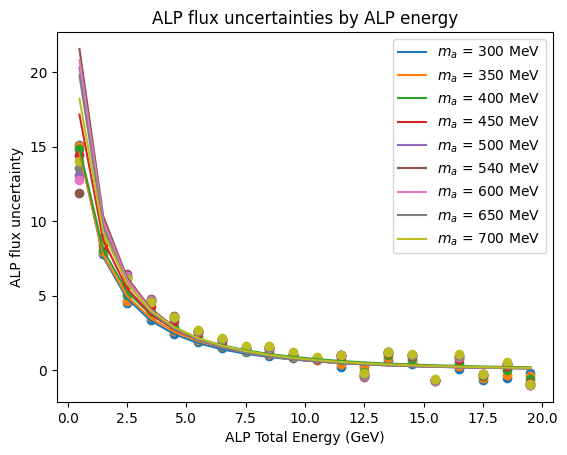

In [37]:
for nm, m in enumerate(np.unique(alp_mass_from_file)):
    mask = (alp_mass_from_file == m)
    plt.scatter(bin_center[mask], alp_flux_unc[mask])
    plt.plot(bin_center[mask], fit_a[nm]*math.e**(-fit_b[nm]*np.sqrt(bin_center[mask])), 
             label='$m_a$ = %a MeV' % m)

plt.xlabel('ALP Total Energy (GeV)')
plt.ylabel('ALP flux uncertainty')
plt.title('ALP flux uncertainties by ALP energy')
plt.legend()
plt.show()

In [39]:
for c in evtdf.wgt.flux.columns:
    print(c)

('univ_0', '', '', '')
('univ_1', '', '', '')
('univ_2', '', '', '')
('univ_3', '', '', '')
('univ_4', '', '', '')
('univ_5', '', '', '')
('univ_6', '', '', '')
('univ_7', '', '', '')
('univ_8', '', '', '')
('univ_9', '', '', '')
('univ_10', '', '', '')
('univ_11', '', '', '')
('univ_12', '', '', '')
('univ_13', '', '', '')
('univ_14', '', '', '')
('univ_15', '', '', '')
('univ_16', '', '', '')
('univ_17', '', '', '')
('univ_18', '', '', '')
('univ_19', '', '', '')
('univ_20', '', '', '')
('univ_21', '', '', '')
('univ_22', '', '', '')
('univ_23', '', '', '')
('univ_24', '', '', '')
('univ_25', '', '', '')
('univ_26', '', '', '')
('univ_27', '', '', '')
('univ_28', '', '', '')
('univ_29', '', '', '')
('univ_30', '', '', '')
('univ_31', '', '', '')
('univ_32', '', '', '')
('univ_33', '', '', '')
('univ_34', '', '', '')
('univ_35', '', '', '')
('univ_36', '', '', '')
('univ_37', '', '', '')
('univ_38', '', '', '')
('univ_39', '', '', '')
('univ_40', '', '', '')
('univ_41', '', '', '')
('

In [55]:
evtdf

slc                          \
                                     is_clear_cosmic      vertex               
                                                               x           y   
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
0      11       4     13                           0  269.558502    2.262024   
                22    2                            0 -328.746460  -44.236271   
                24    16                           0  282.685699   26.401764   
       14       2     9                            0  233.878632 -114.140533   
                      10                           0  301.434326    9.840454   
..                                               ...         ...         ...   
18     4672     16    24                           0  325.571625  -45.422913   
                18    9                            0  185.821075   54.454376   
                21    1                            0 -237.674835   53.374573   
                22    0                            0 -305.097778 -118.721313   
                51    7                            0  208.396942   80.819878   

                                                                           \
                                                 self    tmatch             
                                               z            eff       pur   
                                                                            
                                                                            
                                                                            
sample __ntuple entry rec.slc..index                                        
0      11       4     13              372.517975  159       NaN       NaN   
                22    2                 6.905352  384       NaN       NaN   
                24    16              340.113129   72       NaN       NaN   
       14       2     9               551.446106  246  0.861263  0.912724   
                      10             -741.615295  243       NaN       NaN   
..                                           ...  ...       ...       ...   
18     4672     16    24             -783.838562  129  0.736462  0.991138   
                18    9              -467.175995  205  0.658582  0.982199   
                21    1               456.269562  121  0.706909  0.977133   
                22    0              -368.275757  235  0.464515  0.926669   
                51    7               135.733185  142  0.766762  0.972160   

                                                                  ...  \
                                          producer          nuid  ...   
                                      idx          crlongtrkdiry  ...   
                                                                  ...   
                                                                  ...   
                                                                  ...   
sample __ntuple entry rec.slc..index                              ...   
0      11       4     13             -999        1     -0.854312  ...   
                22    2              -999        0     -0.952633  ...   
                24    16             -999        1     -0.990900  ...   
       14       2     9                 0        1     -0.275798  ...   
                      10             -999        1     -0.659269  ...   
..                                    ...      ...           ...  ...   
18     4672     16    24                0        1     -0.632792  ...   
                18    9                 0        1     -0.080258  ...   
                21    1                 0        0     -0.662631  ...   
                22    0                 1        0   

In [56]:
alp_nosup_mcdfs[0]

time         E    M         start  \
                                                                          x   
__ntuple entry rec.mc.prtl..index                                             
0        0     0                   2673.870343  4.292021  0.3 -31512.037109   
         1     0                   2740.844906  1.541934  0.3 -31512.037109   
         2     0                   2664.740255  8.840829  0.3 -31512.037109   
         3     0                   2683.677258  2.576183  0.3 -31512.037109   
         4     0                   5857.375830  0.337639  0.3 -31512.037109   
...                                        ...       ...  ...           ...   
3072     20    0                   2864.643342  0.835891  0.3 -31512.037109   
         21    0                   2720.921329  1.448656  0.3 -31512.037109   
         22    0                   2703.551869  4.058588  0.3 -31512.037109   
         23    0                   2783.875144  1.121379  0.3 -31512.037109   
         24    0                   2687.911741  2.233376  0.3 -31512.037109   

                                                               enter  \
                                             y         z           x   
__ntuple entry rec.mc.prtl..index                                      
0        0     0                  -3364.491211 -73363.25   23.466770   
         1     0                  -3364.491211 -73363.25 -368.489990   
         2     0                  -3364.491211 -73363.25  -76.365059   
         3     0                  -3364.491211 -73363.25 -120.250549   
         4     0                  -3364.491211 -73363.25 -368.489990   
...                                        ...       ...         ...   
3072     20    0                  -3364.491211 -73363.25 -368.489990   
         21    0                  -3364.491211 -73363.25 -368.489990   
         22    0                  -3364.491211 -73363.25 -368.489990   
         23    0                  -3364.491211 -73363.25 -368.489990   
         24    0                  -3364.491211 -73363.25 -368.489990   

                                                                 exit  \
                                            y           z           x   
__ntuple entry rec.mc.prtl..index                                       
0        0     0                  -191.860001  -69.525436  368.489990   
         1     0                   118.055092  702.263733 -283.262878   
         2     0                   -17.808220 -904.950623  368.489990   
         3     0                    -0.392118 -904.950623  368.489990   
         4     0                  -129.935043  284.332458 -106.047554   
...                                       ...         ...         ...   
3072     20    0                  -118.234375 -777.832336  353.525970   
         21    0                   -75.878899 -794.961304  361.047485   
         22    0                    27.063261 -540.612549  249.723877   
         23    0                    19.771324  137.999649  -43.521725   
         24    0                     9.579076 -519.777710  240.639328   

                                                           decay_length  \
                                            y           z                 
__ntuple entry rec.mc.prtl..index                                         
0        0     0                  -157.148926  732.365601  2.942380e+07   
         1     0                   127.585396  904.950623  1.039410e+07   
         2     0                    29.551632  120.427193  6.072161e+07   
         3     0                    51.983734  223.156845  1.758378e+07   
         4     0                  -102.677872  904.950623  1.064651e+06   
...                                       ...         ...           ...   
3072     20    0                   -42.974827  904.950623  5.361757e+06   
         21    0                     1.156832  904.950623  9.739743e+06   
         22    0                    94.387192  904.950623  2.781543e+07   
   

In [ ]:
# cp'ed for reference.
evtdfs_contained_and_exiting = [pd.read_hdf(file, 'evt') for file in higgs_files+alp_nosup_files]
evtdf_contained_and_exiting = jamie_sample_concat(evtdfs_contained_and_exiting)
bsm_mcdfs = [*higgs_mcdfs, *alp_nosup_mcdfs]
bsm_mcdf = jamie_sample_concat(bsm_mcdfs)

merged_df_left = pd.merge(evtdf_contained_and_exiting, bsm_mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
evtdf_contained_and_exiting=merged_df_left.rename(columns={'E':'bsm_E'})


In [52]:
%%time
# This is the cell that adds the flux wgts to evtdf!
cats = make_categories(evtdf, detailed_bsm=True)
df = 0
alp_mass_ind = 0
w = 0
for c in cats:
    if 'ALP' in c.name: 
        print(c.name)
        df = evtdf[c]
        mass = np.array(alp_nosup_masses)[alp_mass_ind]
        mass_fit_a = fit_a[alp_mass_ind]
        mass_fit_b = fit_b[alp_mass_ind]
        mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
        if mass in mass_to_alpSampleIndex.keys():
            i_alp = mass_to_alpSampleIndex[mass]
            i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
        else:
            print("You've got a problem.")
        #print('mass from mcdf: ', alp_nosup_mcdfs[i_alp_mcdf].iloc[0].M)
        oneSigma_flux_wgts = []
        
        oneSigma_flux_wgts = mass_fit_a*math.e**(-mass_fit_b*np.sqrt(evtdf[c].bsm_E))
        
        #for idx in evtdf[c].index:
        #    #if mass==0.4: print(idx)
        #    row = alp_nosup_mcdfs[i_alp_mcdf].loc[(idx[1],idx[2], 0)]
        #    oneSigma_flux_wgt = mass_fit_a*math.e**(-mass_fit_b*np.sqrt(row.E))
        #    oneSigma_flux_wgts.append(oneSigma_flux_wgt)
        #oneSigma_flux_wgts = np.array(oneSigma_flux_wgts)
        
        for uni in evtdf[c].wgt.flux.columns:
            shift = np.random.normal(size=evtdf[c].shape[0])
            w = oneSigma_flux_wgts*np.abs(shift) 
            #evtdf[c].wgt.flux[uni] = np.array(w) # This line doesn't work b/c the masking is complicated, so it's acting on a copy of the dataframe, not the actual df. See: https://stackoverflow.com/questions/17995328/changing-values-in-pandas-dataframe-does-not-work. Line below works.
            evtdf.loc[c, ('wgt', 'flux', *uni)] = w
            #display(evtdf.loc[c, ('wgt', 'flux', *uni)])
        alp_mass_ind = alp_mass_ind + 1
    
    

$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'


NameError: name 'fit_a' is not defined

In [ ]:
# December 16, 2025

In [93]:
rate_file = "/exp/icarus/data/users/jdyer/muon_selection/alp_flux_uncertainty/rate_table_logbin.txt"
#rate_file = "/exp/icarus/data/users/jdyer/muon_selection/alp_flux_uncertainty/rate_table_pctbin.txt"
#rate_file = "/exp/icarus/data/users/jdyer/muon_selection/alp_flux_uncertainty/rate_table.txt"
file_mass = []
E_low_bin_bound = [] 
E_hi_bin_bound = [] 
R_pythia = [] # only considers primaries
dR_pythia = []
R_g4_primOnly = []
dR_g4_primOnly = []
R_g4_wSec = []
dR_g4_wSec = []
not_first_line = False
with open(rate_file, 'r') as file:
    for line in file:
        if not_first_line:
            this_line = line.strip().split('\t')
            file_mass.append(int(this_line[0]))
            E_low_bin_bound.append(float(this_line[1])) 
            E_hi_bin_bound.append(float(this_line[2])) 
            R_pythia.append(float(this_line[3])) 
            dR_pythia.append(float(this_line[4])) 
            R_g4_primOnly.append(float(this_line[5])) 
            dR_g4_primOnly.append(float(this_line[6])) 
            R_g4_wSec.append(float(this_line[7])) 
            dR_g4_wSec.append(float(this_line[8]))
        else:
            not_first_line = True


In [94]:
E_low_bin_bound = np.array(E_low_bin_bound)
E_hi_bin_bound = np.array(E_hi_bin_bound)
R_pythia = np.array(R_pythia) 
R_g4_primOnly = np.array(R_g4_primOnly) 
R_g4_wSec = np.array(R_g4_wSec) 


In [151]:
# skip
mask_300MeV = (np.array(file_mass)==300)
E_low_bin_bound = np.array(E_low_bin_bound)[mask_300MeV] 
E_hi_bin_bound = np.array(E_hi_bin_bound)[mask_300MeV] 


In [158]:
# skip
print(E_low_bin_bound)
print(E_hi_bin_bound)
print(E_hi_bin_bound[-1])

E_bin_bounds = np.concatenate((E_low_bin_bound, np.array([E_hi_bin_bound[-1]])))
print(E_bin_bounds)

[ 0.135       0.17421232  0.22481431  0.29011424  0.37438129  0.48312469
  0.62345387  0.80454329  1.03823224  1.33979886  1.72895901  2.23115525
  2.87922022  3.71552319  4.79474008  6.18742805  7.98463843 10.30386945
 13.29674807 17.15894307]
[ 0.17421232  0.22481431  0.29011424  0.37438129  0.48312469  0.62345387
  0.80454329  1.03823224  1.33979886  1.72895901  2.23115525  2.87922022
  3.71552319  4.79474008  6.18742805  7.98463843 10.30386945 13.29674807
 17.15894307 22.14295749]
22.14295748548673
[ 0.135       0.17421232  0.22481431  0.29011424  0.37438129  0.48312469
  0.62345387  0.80454329  1.03823224  1.33979886  1.72895901  2.23115525
  2.87922022  3.71552319  4.79474008  6.18742805  7.98463843 10.30386945
 13.29674807 17.15894307 22.14295749]


In [95]:
E_low_bin_bounds = []
E_hi_bin_bounds = []
R_pythias = []
R_g4_primOnlys = []
R_g4_wSecs = []
for um in np.unique(np.array(file_mass)):
    m_mask = (np.array(file_mass)==um)
    E_low_bin_bounds.append(E_low_bin_bound[m_mask])
    E_hi_bin_bounds.append(E_hi_bin_bound[m_mask])
    R_pythias.append(R_pythia[m_mask])
    R_g4_primOnlys.append(R_g4_primOnly[m_mask])
    R_g4_wSecs.append(R_g4_wSec[m_mask])
#E_low_bin_bounds = np.array(E_low_bin_bounds)
#E_hi_bin_bounds = np.array(E_hi_bin_bounds)
#R_pythias = np.array(R_pythias)
#R_g4_primOnlys = np.array(R_g4_primOnlys)
#R_g4_wSecs = np.array(R_g4_wSecs)

In [17]:
print(np.array(R_g4_primOnlys[0])/np.array(R_pythias[0]))
print(np.array(R_g4_primOnlys[1])/np.array(R_pythias[1]))
print(np.array(R_g4_primOnlys[2])/np.array(R_pythias[2]))

[6.18921309 2.79589935 3.11986864 3.02480339 2.64615893 3.19561153
 2.44292446 2.3149418  2.09447052 1.98453381 1.84095349 1.66074552
 1.50358551 1.27914713 1.17935417 1.010173   0.87843528 0.62776851
 0.4777009  0.37929249]
[6.18921309 2.79589935 3.11986864 3.02480339 2.64615893 3.18758061
 2.437437   2.30100344 2.05788048 1.93185925 1.76481442 1.63899372
 1.44290079 1.23762683 1.12445862 1.03168936 0.85632526 0.62305356
 0.62950044 0.36106026]
[6.18921309 2.79589935 3.11986864 3.02480339 2.64615893 3.16333345
 2.42170593 2.26392362 1.9670154  1.80656741 1.59575307 1.59098892
 1.32239548 1.15913803 1.02871694 1.06413887 0.82264054 0.61500843
 0.82737938 0.33689857]


In [142]:
cats = make_categories(evtdf, detailed_bsm=True)
evtdf[cats[8]].bsm_E

sample  __ntuple  entry  rec.slc..index
8       1         0      0                 2.879420
                  2      0                 2.234332
                  11     0                 1.392578
                  14     0                 2.602402
                  19     13                1.688804
                                             ...   
        3064      3      0                 2.404482
                  8      0                 2.210426
                  15     1                 3.868862
                  20     0                 1.587508
                  23     0                 3.509006
Name: bsm_E, Length: 17668, dtype: float64

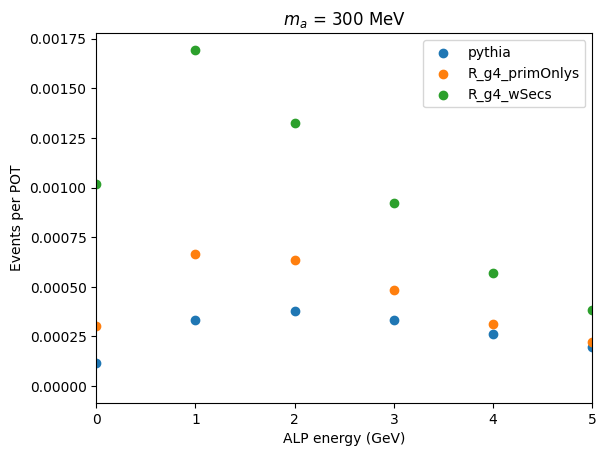

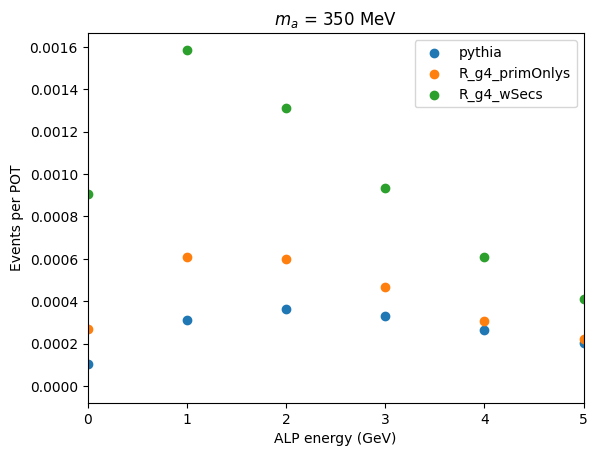

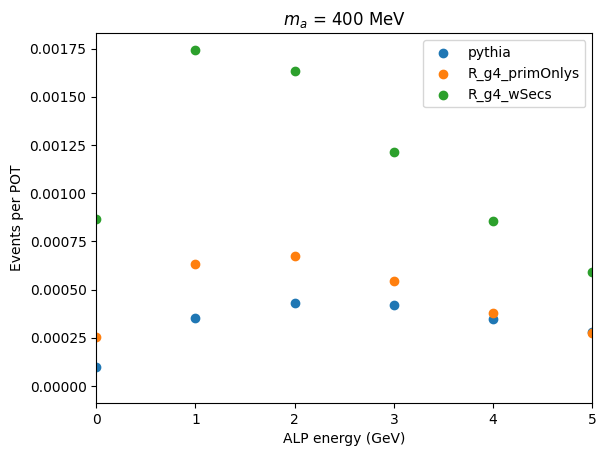

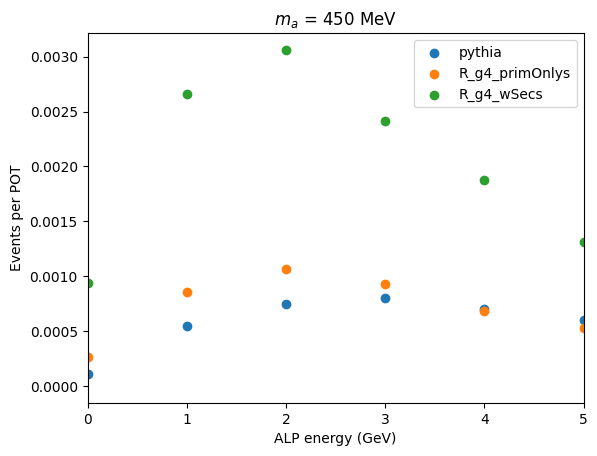

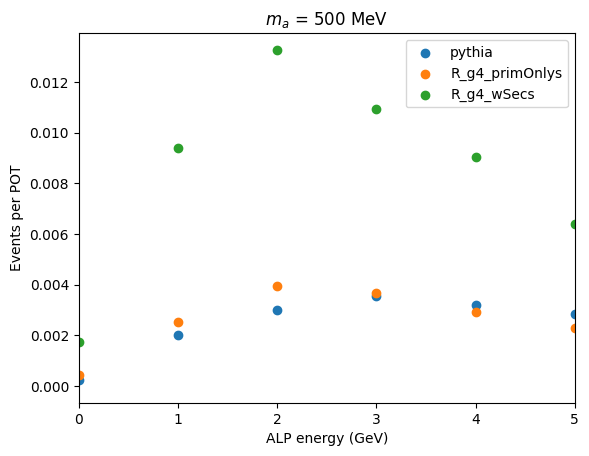

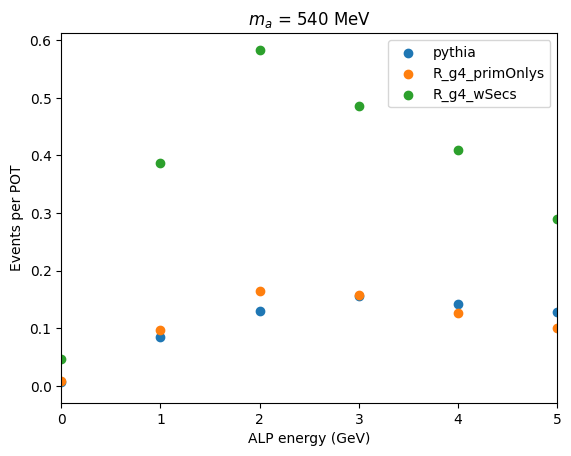

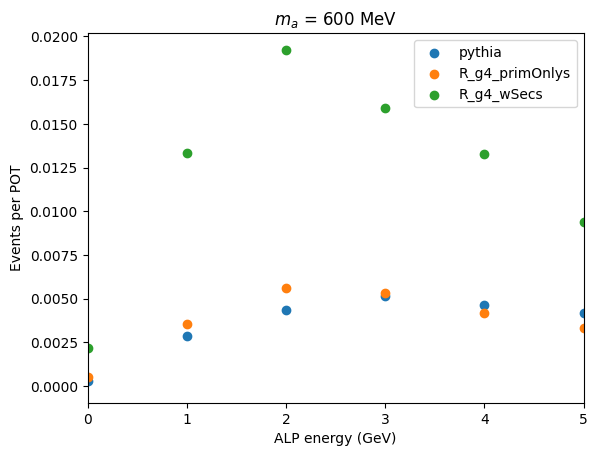

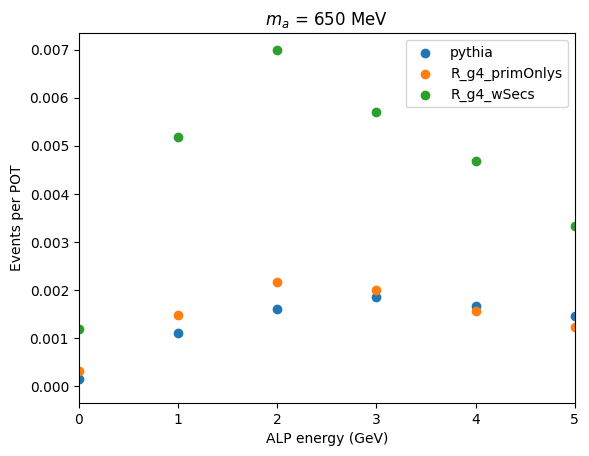

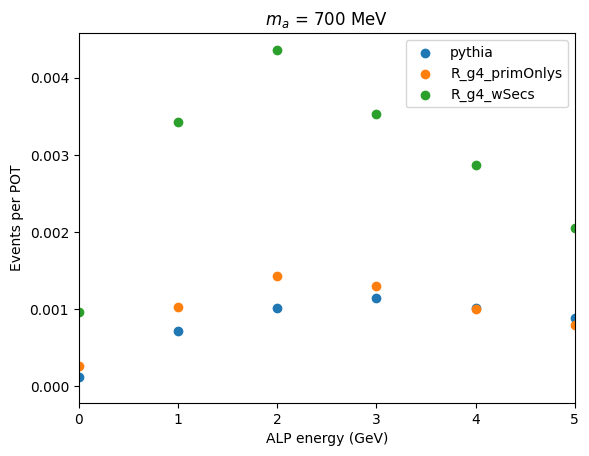

In [47]:
for i, m in enumerate(alp_nosup_masses):
    plt.scatter(E_low_bin_bounds[i], R_pythias[i], label='pythia')
    plt.scatter(E_low_bin_bounds[i], R_g4_primOnlys[i], label='R_g4_primOnlys')
    plt.scatter(E_low_bin_bounds[i], R_g4_wSecs[i], label='R_g4_wSecs')
    plt.xlabel('ALP energy (GeV)')
    plt.ylabel('Events per POT')
    plt.legend()
    plt.title('$m_a$ = %a MeV' % m)
    plt.xlim((0,5))
    #plt.ylim((0., 0.0002))
    plt.show()


    
    

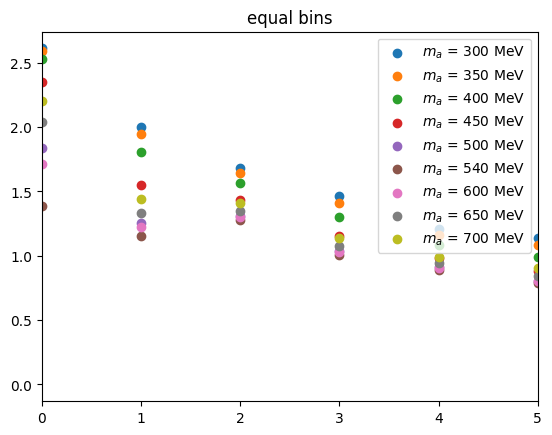

In [92]:
for i, m in enumerate(alp_nosup_masses):
    #if i > 2: 
    #    continue
    plt.scatter(E_low_bin_bounds[i], R_g4_primOnlys[i]/R_pythias[i], label = '$m_a$ = %a MeV' % m)
plt.legend()
plt.xlim((0,5))
plt.title('equal bins')
plt.show()

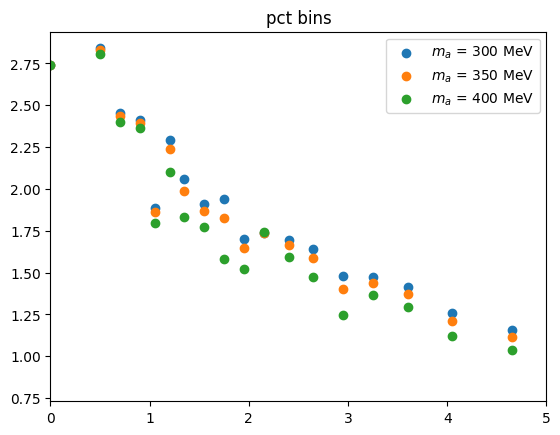

In [42]:
for i, m in enumerate(alp_nosup_masses):
    #if i > 2: 
    #    continue
    plt.scatter(E_low_bin_bounds[i], R_g4_primOnlys[i]/R_pythias[i], label = '$m_a$ = %a MeV' % m)
plt.legend()
plt.xlim((0,5))
plt.title('pct bins')
plt.show()

In [96]:
def get_flux_w(alpE, alp_mass_ind):
    #print('alpE: ', alpE)
    E_bin_bounds = np.concatenate((E_low_bin_bounds[alp_mass_ind], np.array([E_hi_bin_bounds[alp_mass_ind][-1]])))
    try:
        lower_ind = np.where(E_bin_bounds>alpE)[0][0]-1
        upper_ind = np.where(E_bin_bounds>alpE)[0][0]
    except IndexError: # the ALP energy is higher than the max of the range we have rates for.
        # In this case, treat last energy bin as overflow bin
        lower_ind = len(E_bin_bounds)-2
        upper_ind = len(E_bin_bounds)-1
    Npythia = R_pythias[alp_mass_ind][lower_ind]
    Ng4 = R_g4_primOnlys[alp_mass_ind][lower_ind]
    w = Ng4/Npythia - 1
    #print(alpE, w, sep=', ')
    return(w)


9
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'


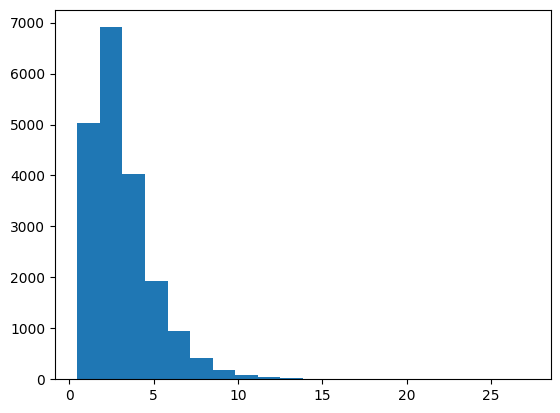

[0.32239547531967294, 0.32239547531967294, 0.1591380291246678, 0.5909889156979247, 0.5957530744406736, 0.028716935816155642, 0.8065674052703862, 0.5957530744406736, 0.9670154009633709, 0.8065674052703862, 0.1591380291246678, 0.5957530744406736, 0.5909889156979247, 0.5909889156979247, 0.1591380291246678, 0.32239547531967294, 0.32239547531967294, 0.1591380291246678, 0.1591380291246678, 0.5909889156979247, 0.5957530744406736, 0.8065674052703862, 0.8065674052703862, 0.8065674052703862, 1.2639236210461493, 0.5909889156979247, 0.5909889156979247, 0.028716935816155642, 0.9670154009633709, 0.5957530744406736, 1.2639236210461493, 0.5909889156979247, 0.1591380291246678, 0.5909889156979247, 0.8065674052703862, 1.2639236210461493, 0.5957530744406736, 1.4217059315792562, 0.5957530744406736, 0.9670154009633709, 0.8065674052703862, 2.1633334489802865, 0.028716935816155642, 0.028716935816155642, 0.1591380291246678, 0.32239547531967294, 0.028716935816155642, 0.1591380291246678, 0.5957530744406736, 0.59

In [98]:
print(len(E_low_bin_bounds))
#for cat in cats:
#    print(cat.name)
#print(E_low_bin_bounds[1])
#print(E_low_bin_bounds[2])
print(cats[9].name)
plt.hist(evtdf[cats[9]].bsm_E, bins=20)
plt.show()
alpFluxRatios = [get_flux_w(x, 2)for x in evtdf[cats[9]].bsm_E]
print(alpFluxRatios)
#diffs



In [176]:
x = 2.879420
print(E_bin_bounds)
lower_inds = [np.where(E_bin_bounds>x)[0][0]-1 for x in evtdf[cats[8]].bsm_E]
upper_inds = [np.where(E_bin_bounds>x)[0][0] for x in evtdf[cats[8]].bsm_E]
print(len(lower_inds))

##inds = np.where(E_bin_bounds>evtdf[c].bsm_E)[0]
#lower_ind = inds[0]-1
#upper_ind = inds[0]
#print(E_bin_bounds[lower_ind])
#print(E_bin_bounds[upper_ind])
## evtdf[c].bsm_E
##print(E_bin_bounds.index(first_match_or_none))


[ 0.135       0.17421232  0.22481431  0.29011424  0.37438129  0.48312469
  0.62345387  0.80454329  1.03823224  1.33979886  1.72895901  2.23115525
  2.87922022  3.71552319  4.79474008  6.18742805  7.98463843 10.30386945
 13.29674807 17.15894307 22.14295749]
17668


In [99]:
#%%time
# This is the cell that adds the flux wgts to evtdf!
cats = make_categories(evtdf, detailed_bsm=True)
df = 0
alp_mass_ind = 0
w = 0
for c in cats:
    if 'ALP' in c.name: 
        print(c.name)
        print(alp_mass_ind)
        df = evtdf[c]
        mass = np.array(alp_nosup_masses)[alp_mass_ind]
        #mass_fit_a = fit_a[alp_mass_ind]
        #mass_fit_b = fit_b[alp_mass_ind]
        mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
        if mass in mass_to_alpSampleIndex.keys():
            i_alp = mass_to_alpSampleIndex[mass]
            i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
        else:
            print("You've got a problem.")
        #print('mass from mcdf: ', alp_nosup_mcdfs[i_alp_mcdf].iloc[0].M)
        
        #oneSigma_flux_wgts = mass_fit_a*math.e**(-mass_fit_b*np.sqrt(evtdf[c].bsm_E))
        
        alpFluxRatios = np.array([get_flux_w(x, alp_mass_ind)for x in evtdf[c].bsm_E])
        
        for uni in evtdf[c].wgt.flux.columns:
            #shift = np.random.normal(size=evtdf[c].shape[0])
            #w = oneSigma_flux_wgts*np.abs(shift) 
            ##evtdf[c].wgt.flux[uni] = np.array(w) # This line doesn't work b/c the masking is complicated, so it's acting on a copy of the dataframe, not the actual df. See: https://stackoverflow.com/questions/17995328/changing-values-in-pandas-dataframe-does-not-work. Line below works.
            #evtdf.loc[c, ('wgt', 'flux', *uni)] = w
            
            shift = np.random.normal()
            #w = 1 + diffs*np.abs(shift)
            w = 1 + alpFluxRatios*np.abs(shift)
            evtdf.loc[c, ('wgt', 'flux', *uni)] = w
            #display(evtdf.loc[c, ('wgt', 'flux', *uni)])
        alp_mass_ind = alp_mass_ind + 1
    

$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
0
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
1
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
2
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
3
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
4
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
5
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
6
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
7
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'
8


In [100]:
ic = 9
print(cats[ic].name)
evtdf[cats[ic]].wgt.flux



$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'


univ_0    univ_1    univ_2    univ_3  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
9      0        1     0               1.463224  1.645199  1.107297  1.358057   
                4     0               1.463224  1.645199  1.107297  1.358057   
                5     0               1.228652  1.318478  1.052963  1.176741   
                14    15              1.849144  2.182726  1.196689  1.656361   
                15    2               1.855989  2.192261  1.198274  1.661652   
...                                        ...       ...       ...       ...   
       3049     4     21              1.855989  2.192261  1.198274  1.661652   
                12    0               2.158891  2.614157  1.268436  1.895786   
                14    0               2.158891  2.614157  1.268436  1.895786   
                15    0               1.228652  1.318478  1.052963  1.176741   
                18    14              1.463224  1.645199  1.107297  1.358057   

                                        univ_4    univ_5    univ_6    univ_7  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
9      0        1     0               1.453226  1.287900  1.217111  1.281857   
                4     0               1.453226  1.287900  1.217111  1.281857   
                5     0               1.223717  1.142111  1.107169  1.139128   
                14    15              1.830817  1.527755  1.397990  1.516677   
                15    2               1.837514  1.532009  1.401199  1.520842   
...                                        ...       ...       ...       ...   
       3049     4     21              1.837514  1.532009  1.401199  1.520842   
                12    0               2.133879  1.720267  1.543168  1.705148   
                14    0               2.133879  1.720267  1.543168  1.705148   
                15    0               1.223717  1.142111  1.107169  1.139128   
                18    14              1.453226  1.287900  1.217111  1.281857   

                                        univ_8    univ_9  ...   univ_90  \
                                                          ...             
                                                          ...             
                                                          ...             
sample __ntuple entry rec.slc..index                      ...             
9      0        1     0               1.066125  1.421300  ...  1.029135   
                4     0               1.066125  1.421300  ...  1.029135   
                5     0               1.032640  1.207958  ...  1.014381   
                14    15              1.121216  1.772293  ...  1.053407   
                15    2               1.122193  1.778519  ...  1.053838   
...                                        ...       ...  ...       ...   
       3049     4     21              1.122193  1.778519  ...  1.053838   
                12    0               1.165432  2.054007  ...  1.072889   
                14    0               1.165432  2.054007  ...  1.072889   
                15    0               1.032640  1.207958  ...  1.014381   
                18    14              1.066125  1.421300  ...  1.029135   

                                       univ_91   univ_92   univ_93   univ_94  \
                                                                               
                                                                               
                                     

In [188]:
evtdf[cats[3]].wgt.flux


univ_0    univ_1    univ_2    univ_3  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
3      11       6     21              1.078444  0.986973  1.019449  0.941156   
                30    0               0.895851  1.019081  0.912237  0.922581   
                32    0               0.913908  0.929405  0.881580  0.775681   
                43    13              1.012957  1.099385  1.029804  1.016282   
       8        28    13              0.924869  0.937785  0.877673  0.768926   
...                                        ...       ...       ...       ...   
       1009     24    0               0.896890  0.963071  0.907332  0.839403   
                28    0               0.913908  0.929405  0.881580  0.775681   
                30    21              1.054239  1.008361  1.014667  0.979027   
                34    0               1.072083  1.034169  1.012688  0.927881   
                36    18              1.078444  0.986973  1.019449  0.941156   

                                        univ_4    univ_5    univ_6    univ_7  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
3      11       6     21              0.889663  0.911741  0.946424  0.777805   
                30    0               0.875343  0.907261  1.136475  0.939640   
                32    0               0.957539  0.867303  0.887866  0.908460   
                43    13              0.994913  0.857279  0.883834  0.720369   
       8        28    13              0.942623  0.877070  0.890100  0.924917   
...                                        ...       ...       ...       ...   
       1009     24    0               0.938007  0.854789  0.862455  0.842953   
                28    0               0.957539  0.867303  0.887866  0.908460   
                30    21              1.019921  0.956450  1.166816  0.919978   
                34    0               0.911507  0.942377  1.035699  0.902322   
                36    18              0.889663  0.911741  0.946424  0.777805   

                                        univ_8    univ_9  ...   univ_90  \
                                                          ...             
                                                          ...             
                                                          ...             
sample __ntuple entry rec.slc..index                      ...             
3      11       6     21              0.983365  0.969173  ...  0.881442   
                30    0               0.909533  0.942040  ...  0.914110   
                32    0               0.959206  0.950538  ...  0.916539   
                43    13              1.058701  0.989319  ...  0.919716   
       8        28    13              0.976431  0.951704  ...  0.898336   
...                                        ...       ...  ...       ...   
       1009     24    0               0.963262  0.970056  ...  0.895945   
                28    0               0.959206  0.950538  ...  0.916539   
                30    21              1.002274  1.060206  ...  1.041757   
                34    0               1.001329  0.997889  ...  0.937164   
                36    18              0.983365  0.969173  ...  0.881442   

                                       univ_91   univ_92   univ_93   univ_94  \
                                                                               
                                                                               
                                     

### Print # signal and bg and associated uncertainties, given a set of cuts:

In [19]:
evtdf.wgt["all"]

univ_0    univ_1    univ_2    univ_3  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
0      11       4     13              1.000000  1.000000  1.000000  1.000000   
                22    2               1.000000  1.000000  1.000000  1.000000   
                24    16              1.000000  1.000000  1.000000  1.000000   
       14       2     9               0.980555  0.935272  0.982781  0.973836   
                      10              1.000000  1.000000  1.000000  1.000000   
...                                        ...       ...       ...       ...   
18     4672     16    24              0.217088  1.045073  0.376516  0.962329   
                18    9               1.548118  1.459575  1.564464  2.078666   
                21    1               1.065373  0.472915  0.362012  0.609565   
                22    0               2.000687  0.802510  0.044306  0.608583   
                51    7               1.470548  1.368273  0.341071  0.543965   

                                        univ_4    univ_5    univ_6    univ_7  \
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
0      11       4     13              1.000000  1.000000  1.000000  1.000000   
                22    2               1.000000  1.000000  1.000000  1.000000   
                24    16              1.000000  1.000000  1.000000  1.000000   
       14       2     9               0.887970  0.956066  0.854714  0.902960   
                      10              1.000000  1.000000  1.000000  1.000000   
...                                        ...       ...       ...       ...   
18     4672     16    24              1.140932  0.367537  0.096101  2.089038   
                18    9               2.340571  2.034373  0.967490  1.149128   
                21    1               0.881857  0.687731  0.177112  1.067363   
                22    0               0.701935  0.423069  0.175224  1.265175   
                51    7               1.080175  0.412437  0.247722  0.996205   

                                        univ_8    univ_9  ...   univ_90  \
                                                          ...             
                                                          ...             
                                                          ...             
sample __ntuple entry rec.slc..index                      ...             
0      11       4     13              1.000000  1.000000  ...  1.000000   
                22    2               1.000000  1.000000  ...  1.000000   
                24    16              1.000000  1.000000  ...  1.000000   
       14       2     9               0.954174  0.965591  ...  0.929048   
                      10              1.000000  1.000000  ...  1.000000   
...                                        ...       ...  ...       ...   
18     4672     16    24              0.090285  0.303005  ...  2.831044   
                18    9               1.495231  1.136992  ...  0.906558   
                21    1               0.257432  1.437502  ...  1.987693   
                22    0               0.413355  1.943005  ...  0.729021   
                51    7               0.538318  2.090974  ...  0.550528   

                                       univ_91   univ_92   univ_93   univ_94  \
                                                                               
                                                                               
                                     

In [36]:
cats = make_categories(evtdf, detailed_nu='none')
[print(c.name) for c in cats]
bsm_evtdf = evtdf[cats[0]]

BSM
MC $
u$
Cosmic


In [38]:
for c in evtdf.columns: #.wgt.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [45]:

evtdf[evtdf['hps']==True]

slc                          \
                                     is_clear_cosmic      vertex               
                                                               x           y   
                                                                               
                                                                               
                                                                               
sample __ntuple entry rec.slc..index                                           
0      11       4     13                           0  269.558502    2.262024   
                22    2                            0 -328.746460  -44.236271   
                24    16                           0  282.685699   26.401764   
       14       2     9                            0  233.878632 -114.140533   
                      10                           0  301.434326    9.840454   
..                                               ...         ...         ...   
6      1905     39    0                            0 -166.163376   87.459045   
                      1                            0 -202.582962   98.971191   
                42    10                           0  146.600540  -93.018097   
                43    0                            0  -85.030609  -20.664795   
                46    1                            0 -123.186714   27.660004   

                                                                           \
                                                 self    tmatch             
                                               z            eff       pur   
                                                                            
                                                                            
                                                                            
sample __ntuple entry rec.slc..index                                        
0      11       4     13              372.517975  159       NaN       NaN   
                22    2                 6.905352  384       NaN       NaN   
                24    16              340.113129   72       NaN       NaN   
       14       2     9               551.446106  246  0.861263  0.912724   
                      10             -741.615295  243       NaN       NaN   
..                                           ...  ...       ...       ...   
6      1905     39    0               157.905212  222  0.881058  0.986961   
                      1              -804.348511  223       NaN       NaN   
                42    10              346.347717  121  0.850359  0.999989   
                43    0              -818.292786   79       NaN       NaN   
                46    1               204.075760  237       NaN       NaN   

                                                                  ...  \
                                          producer          nuid  ...   
                                      idx          crlongtrkdiry  ...   
                                                                  ...   
                                                                  ...   
                                                                  ...   
sample __ntuple entry rec.slc..index                              ...   
0      11       4     13             -999        1     -0.854312  ...   
                22    2              -999        0     -0.952633  ...   
                24    16             -999        1     -0.990900  ...   
       14       2     9                 0        1     -0.275798  ...   
                      10             -999        1     -0.659269  ...   
..                                    ...      ...           ...  ...   
6      1905     39    0                 0        0     -0.106638  ...   
                      1              -999        0     -0.466364  ...   
                42    10                0        1     -0.053962  ...   
                43    0              -999        0   

In [59]:
print('min, max flux weights for HPS uni 0:')
print(min(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_0))
print('min, max g4 weights for HPS uni 0:')
print(min(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_0))

#print(max(bsm_evtdf[bsm_evtdf['hps']==True].slc.truth.nmu))
#print(max(bsm_evtdf[bsm_evtdf['hps']==True].slc.truth.npi))
print('')

print('min, max flux weights for ALP uni 0:')
print(min(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_0))
print('min, max g4 weights for ALP uni 0:')
print(min(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_0))

#print(max(bsm_evtdf[bsm_evtdf['alp']==True].slc.truth.nmu))
#print(max(bsm_evtdf[bsm_evtdf['alp']==True].slc.truth.npi))

print('')
#print(bsm_evtdf[bsm_evtdf['alp']==True].shape)
#print(bsm_evtdf[bsm_evtdf['alp']==True & bsm_evtdf].shape)

min, max flux weights for HPS uni 0:
0.16522174533995532 ,  1.7014502527750759
min, max g4 weights for HPS uni 0:
1.0 ,  1.0

min, max flux weights for ALP uni 0:
1.0 ,  1.0
min, max g4 weights for ALP uni 0:
1.0 ,  1.0



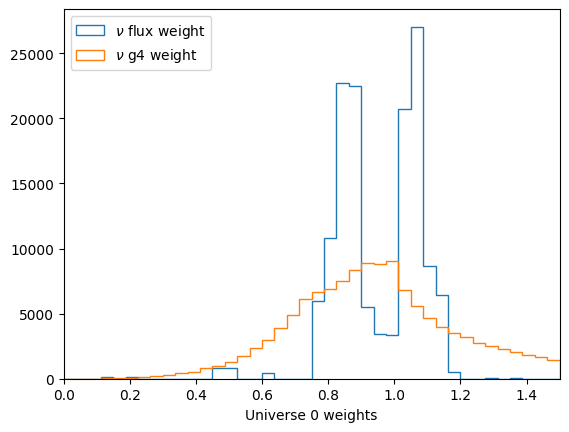

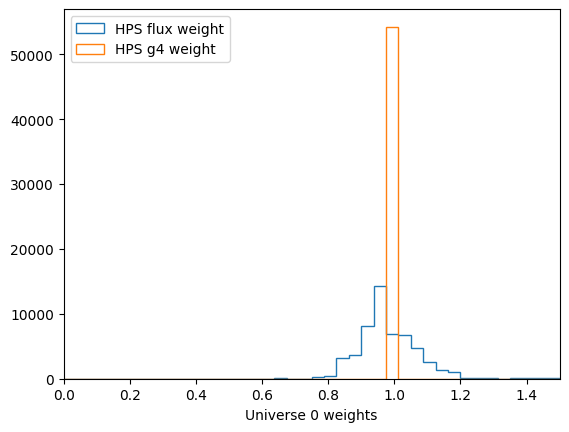

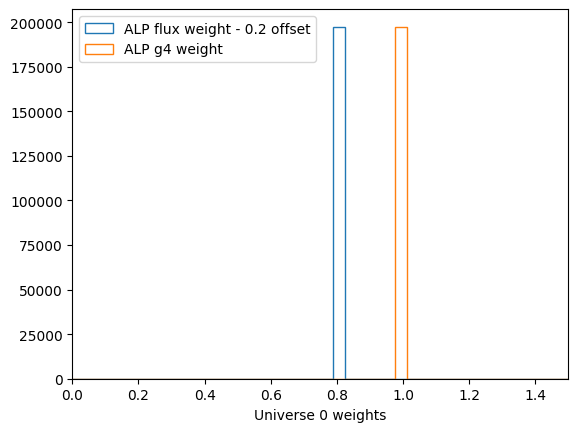

In [37]:

mybins=40
myrange=(0,1.5)
plt.hist(evtdf[cats[1]].wgt.flux.univ_1, label='$\\nu$ flux weight', bins=mybins, histtype='step', range=myrange)
plt.hist(evtdf[cats[1]].wgt.g4.univ_1, label='$\\nu$ g4 weight', bins=mybins, histtype='step', range=myrange)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()
# Q: Is the dis. for the nus from kaons bimodal too? If so, weird that its different from HPS.

plt.hist(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_1, label='HPS flux weight', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_1, label='HPS g4 weight', bins=mybins, histtype='step', range=myrange)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()

plt.hist(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_1-0.2, label='ALP flux weight - 0.2 offset', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_1, label='ALP g4 weight', bins=mybins, histtype='step', range=myrange)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()

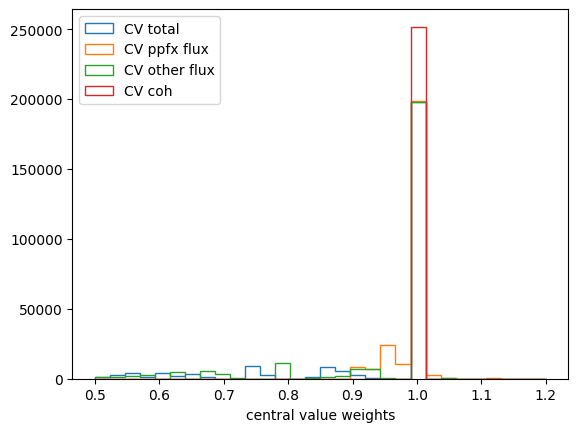

In [40]:
mybins=30
myrange=(0.5,1.2)
plt.hist(bsm_evtdf.wgt.cv.tot, label='CV total', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.ppfx, label='CV ppfx flux', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.flux_other_than_ppfx, label='CV other flux', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.coh, label='CV coh', bins=mybins, histtype='step', range=myrange)
plt.xlabel('central value weights')
plt.legend(loc='upper left')
plt.show()

In [20]:
for c in evtdf.columns: print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [21]:
print(evtdf.shape)
print(evtdf[evtdf.mccoh==True].shape)


(579047, 830)
(108593, 830)


In [101]:
def apply_cuts_and_reweight_signal(df, cuts, thresholds=None, 
                                   detailed_bsm=True, detailed_nu='int_type', 
                                   mccoh_detVar_dfs = mccoh_detVar_evtdfs,
                                   do_model_reweights=False
                                  ):

    ogcats = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    # Initialize the dataframe to display:
    display_df = pd.DataFrame(
        np.zeros((0,len(ogcats)), dtype=int), # start w/ zero rows (cuts), fill later
        columns = [c.name for c in ogcats]
    )
    display_df = display_df.T
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
    
    # Count events by category: MC, POT-normalized, and POT-normalized w/ reweights to different model benchmarks
    selected_df = df[master_mask]
    total_mc = []
    total_POT_normed = []
    stat_unc_by_cat = []
    POT_normed_unc_by_cat_coh = []
    POT_normed_unc_by_cat_xsec = []
    POT_normed_unc_by_cat_flux = []
    POT_normed_unc_by_cat_g4 = []
    POT_normed_unc_by_cat = [] # 12/2/25 TODO: take care of this in the following for loop.
    total_POT_normed_rwt_to_fa_E5 = []
    categories = make_categories(selected_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    alp_mass_ind = 0
    
    for c in categories:
        
        #c = [True]*selected_df.shape[0]
        
        total_mc.append(selected_df[c].shape[0])
        total_POT_normed.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot))
        
        # MC Statistical
        stat_unc_by_cat.append(np.sqrt(np.sum((selected_df[c].scale*selected_df[c].wgt.cv.tot)**2)))
        
        # ~~~~~~ SUM OVER UNIVERSES. 
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions): # ["coh", "xsec", "flux", "g4"]
            hcov = None # 1
            uni_counter = 0
            for col in selected_df[c].wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                uni_counter = uni_counter + 1
                uni_weight = np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].wgt[uni_cont][col])
                this_cov = (np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot)-uni_weight)**2
                if hcov is None:
                    hcov = this_cov
                else:
                    hcov += this_cov
            universe_covs.append(hcov/uni_counter)
        POT_normed_unc_by_cat_coh.append(np.sqrt(universe_covs[0]))
        POT_normed_unc_by_cat_xsec.append(np.sqrt(universe_covs[1]))
        POT_normed_unc_by_cat_flux.append(np.sqrt(universe_covs[2]))
        POT_normed_unc_by_cat_g4.append(np.sqrt(universe_covs[3]))
        
        ## ~~ together ("all" = coh * xsec * flux * g4)
        #hcov = None #2
        #nuni = len(selected_df[c].wgt["all"].columns)
        #for col in selected_df[c].wgt["all"].columns:
        #    if not col[0].startswith("univ"): continue
        #    uni_weight = np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].wgt["all"][col])
        #    this_cov = (np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot)-uni_weight)**2
        #    if hcov is None:
        #        hcov = this_cov
        #    else:
        #        hcov += this_cov
        #POT_normed_unc_by_cat.append(hcov/nuni)
        
        if do_model_reweights:
            if 'ALP' in c.name:
                mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
                #print(mass, ', ', c.name)
                reweigts_psuedomixed_alps = []
                if mass in mass_to_alpSampleIndex.keys():
                    i_alp = mass_to_alpSampleIndex[mass]
                    i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
                    old_fa = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C1)
                    old_cmu = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C2)        
                    old_alp_f = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[0].allowed_decay_fraction)    
                    reweigts_psuedomixed_alps = []
                    #display(alp_nosup_mcdfs[i_alp_mcdf])
                    for idx in selected_df[c].index:
                        #if mass==0.4: print(idx)
                        row = alp_nosup_mcdfs[i_alp_mcdf].loc[(idx[1],idx[2], 0)]
                        factor_rwgt_producedAlps = float(
                            reweight_alps(old_fa, 10**5, old_cmu, 0.01, 
                                          row.start, row.enter, row.exit, 
                                          row.decay_length, old_alp_f)
                        )
                        reweigts_psuedomixed_alps.append(factor_rwgt_producedAlps)
                    total_POT_normed_rwt_to_fa_E5.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*reweigts_psuedomixed_alps))
                    mass = round(mass+0.05,2)
                else: (print('Uh-oh, dont know alp mcdf info!'))
                alp_mass_ind = alp_mass_ind+1
            else:
                total_POT_normed_rwt_to_fa_E5.append(-1)
    
    display_df['# MC events']=total_mc
    display_df['POT normed']=total_POT_normed
    
    display_df['MC stat. unc.'] = np.array(stat_unc_by_cat)/np.array(total_POT_normed)
    
    print('POT_normed_unc_by_cat_coh: ', POT_normed_unc_by_cat_coh)
    print('POT_normed_unc_by_cat_xsec: ', POT_normed_unc_by_cat_xsec)
    print('POT_normed_unc_by_cat_flux: ', POT_normed_unc_by_cat_flux)
    print('POT_normed_unc_by_cat_g4: ', POT_normed_unc_by_cat_g4)
    
    display_df['coh_xs syst.'] = np.array(POT_normed_unc_by_cat_coh)/np.array(total_POT_normed)
    display_df['incoh_xs syst.'] = np.array(POT_normed_unc_by_cat_xsec)/np.array(total_POT_normed)
    display_df['flux syst.'] = np.array(POT_normed_unc_by_cat_flux)/np.array(total_POT_normed)
    display_df['g4 syst.'] = np.array(POT_normed_unc_by_cat_g4)/np.array(total_POT_normed)                       
                                        
    #display_df['coh_xs, incoh_xs, g4, \n& flux syst.'] = POT_normed_unc_by_cat/total_POT_normed
    
    display_df['detector syst.'] = [-1]*len(total_POT_normed)
    display_df['Total unc.'] = [-1]*len(total_POT_normed)
    if do_model_reweights: 
        display_df['POT normed, rwt to fa=E5']=total_POT_normed_rwt_to_fa_E5
    
    sum_of_bg = display_df.iloc[16:].sum(axis=0)
    display_df.loc['Total BG']=sum_of_bg
    total_bg = float(display_df.loc['Total BG']['POT normed'])
    print('total_bg: ', total_bg)
        
    # CALCULATE THE TOTAL UNCERTAINTY ON BACKGROUND (not by category):

    coarse_cats = make_categories(selected_df, detailed_bsm=False, detailed_nu='none')
    selected_bgdf = selected_df[coarse_cats[1] | coarse_cats[2]]
    print('total bg calculated from selected_bgdf: ', np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot))
    
    # statistical:
    mc_stat_err = np.sqrt(np.sum((selected_bgdf.scale*selected_bgdf.wgt.cv.tot)**2))
    print('selected_bgdf.shape: ', selected_bgdf.shape)
    print('mc_stat_err: ', mc_stat_err)
    
    display_df.loc['Total BG']['MC stat. unc.'] = mc_stat_err/total_bg
    
    # ~~~~~~ SUM OVER UNIVERSES. 
        
    # ~~ separate (#coh, #xsec, #flux, #g4)
    universe_contributions = ["coh", "xsec", "flux", "g4"]
    universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
    universe_covs = []
    for uc, uni_cont in enumerate(universe_contributions): # ["coh", "xsec", "flux", "g4"]
        hcov = None #3
        uni_counter = 0
        for col in selected_bgdf.wgt[uni_cont].columns:
            if not col[0].startswith("univ"): continue
            uni_counter = uni_counter + 1
            uni_weight = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot*selected_bgdf.wgt[uni_cont][col])
            this_cov = (total_bg-uni_weight)**2
            if hcov is None:
                hcov = this_cov
            else:
                hcov += this_cov
        universe_covs.append(hcov/uni_counter)
    coh_cov = universe_covs[0]
    xsec_cov = universe_covs[1]
    flux_cov = universe_covs[2]
    g4_cov = universe_covs[3]
        
    display_df.loc['Total BG']['coh_xs syst.'] = np.sqrt(coh_cov)/total_bg
    display_df.loc['Total BG']['incoh_xs syst.'] = np.sqrt(xsec_cov)/total_bg
    display_df.loc['Total BG']['flux syst.'] = np.sqrt(flux_cov)/total_bg
    display_df.loc['Total BG']['g4 syst.'] = np.sqrt(g4_cov)/total_bg
        
    # ~~ together ("all" = coh * xsec * flux * g4)
    
    uni_weights = []
    hcov = None #4
    for col in selected_bgdf.wgt["all"].columns:
        if not col[0].startswith("univ"): continue
        uni_weight = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot*selected_bgdf.wgt["all"][col])
        uni_weights.append(uni_weight)
        this_cov = (total_bg-uni_weight)**2
        if hcov is None:
            hcov = this_cov
        else:
            hcov += this_cov
    #print('hcov: ', hcov)
    #print('len(uni_weights): ', len(uni_weights))
    Universe_cov = hcov / len(uni_weights)
    #print('Universe_cov: ', Universe_cov)
    #display_df.loc['Total BG']['coh_xs, incoh_xs, g4, \n& flux systematics'] = np.sqrt(Universe_cov)/total_bg
    print('Total systematic unc on bg from coh_xs, incoh_xs, g4, flux: ', np.sqrt(Universe_cov))
    print('Total systematic unc on bg from coh_xs, incoh_xs, g4, flux, \
    as calculated from doing them all separately: ', np.sqrt(coh_cov+xsec_cov+flux_cov+g4_cov))
        
    ## ~~~~~~
                
    # BG MC DETECTOR SYSTEMATICS
    
    do_detector_variations=True     
    if do_detector_variations:
        
        # calculate fraction of selected bg events that are cohlike:
        selected_cohlike_mask = (selected_bgdf.mccoh==True)
        selected_cohlike = np.sum(selected_bgdf[selected_cohlike_mask].scale * selected_bgdf[selected_cohlike_mask].wgt.cv.tot)
        #print('selected_cohlike: ', selected_cohlike)
        frac_cohlike = selected_cohlike/total_bg
        print('frac_cohlike: ', frac_cohlike)
        
        # apply event selection to detector variation samples and get cov for each:
        selected_syst_evtdfs = [] # cohlikes
        dv_covs = []
        for d, systdf in enumerate(mccoh_detVar_dfs):
            cut_results = apply_cuts(systdf, cut_list, thresholds=thresholds, detailed_nu='none')
            mask = cut_results[-1]
            sel_systdf = systdf[mask]
            selected_syst_evtdfs.append(sel_systdf)
            dv_covs.append( (total_bg - (1/frac_cohlike)*np.sum(sel_systdf.scale*sel_systdf.wgt.cv.tot))**2 )
        mccoh_detVar_dfs = selected_syst_evtdfs
        total_det_syst_bg = np.sqrt(np.sum(dv_covs))
        print('Total detector uncertainty on total bg: ', total_det_syst_bg)
        display_df.loc['Total BG']['detector syst.'] = total_det_syst_bg/total_bg
        
        total_unc = np.sqrt(Universe_cov + np.sum(dv_covs) + mc_stat_err**2)
        print('Total Uncertainty on total bg: ', total_unc)
        display_df.loc['Total BG']['Total unc.'] = total_unc/total_bg
    
        
    ###
    
    display(display_df)
    return display_df 


In [17]:
print(np.sqrt(55)/55.)



0.13483997249264842


In [102]:
%%time
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]
x = apply_cuts_and_reweight_signal(evtdf, cut_list, thresholds=thresholds,
                                   mccoh_detVar_dfs = mccoh_detVar_evtdfs,
                                   detailed_nu='int_type', detailed_bsm=True)


/tmp/ipykernel_95188/3149728317.py:121: RuntimeWarning: invalid value encountered in divide
  display_df['MC stat. unc.'] = np.array(stat_unc_by_cat)/np.array(total_POT_normed)
/tmp/ipykernel_95188/3149728317.py:128: RuntimeWarning: invalid value encountered in divide
  display_df['coh_xs syst.'] = np.array(POT_normed_unc_by_cat_coh)/np.array(total_POT_normed)
/tmp/ipykernel_95188/3149728317.py:129: RuntimeWarning: invalid value encountered in divide
  display_df['incoh_xs syst.'] = np.array(POT_normed_unc_by_cat_xsec)/np.array(total_POT_normed)
/tmp/ipykernel_95188/3149728317.py:130: RuntimeWarning: invalid value encountered in divide
  display_df['flux syst.'] = np.array(POT_normed_unc_by_cat_flux)/np.array(total_POT_normed)
/tmp/ipykernel_95188/3149728317.py:131: RuntimeWarning: invalid value encountered in divide
  display_df['g4 syst.'] = np.array(POT_normed_unc_by_cat_g4)/np.array(total_POT_normed)


POT_normed_unc_by_cat_coh:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6752501084255599, 0.0, 0.0]
POT_normed_unc_by_cat_xsec:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.024039443364496, 0.027394514653433417, 0.0, 0.0, 0.0]
POT_normed_unc_by_cat_flux:  [4.8079343919005726e-05, 0.0011052228683359692, 0.002454767388038205, 0.0022447827300632285, 0.0016435071582487544, 0.001817166199754803, 0.0012806350747595608, 9.360564044957905e-05, 0.00013850850091801355, 0.00012371114694590717, 0.0001396536617520471, 0.00019641490925275507, 0.003656867485411315, 0.00019465205416822141, 5.0347249076611533e-05, 4.0457453015413216e-05, 0.0, 0.0, 0.0048797196157857586, 0.041621804385432046, 0.08126386589522414, 0.0, 0.0]
POT_normed_unc_by_cat_g4:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01834104873460194, 0.22924393563751, 0.14954457300674884,

/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.

Total detector uncertainty on total bg:  0.7080592954695042
Total Uncertainty on total bg:  1.0789881937878336


/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_95188/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


,# MC events,POT normed,MC stat. unc.,coh_xs syst.,incoh_xs syst.,flux syst.,g4 syst.,detector syst.,Total unc.
"$M_S$ = 220, $\theta_S$ = 1e-05",429.0,0.000645,0.049111,0.000000,0.000000,0.074538,0.000000,-1.000000,-1.000000
"$M_S$ = 240, $\theta_S$ = 1e-05",1205.0,0.009546,0.029281,0.000000,0.000000,0.115782,0.000000,-1.000000,-1.000000
"$M_S$ = 260, $\theta_S$ = 1e-05",1475.0,0.023138,0.026552,0.000000,0.000000,0.106092,0.000000,-1.000000,-1.000000
"$M_S$ = 280, $\theta_S$ = 1e-05",873.0,0.030439,0.034631,0.000000,0.000000,0.073748,0.000000,-1.000000,-1.000000
"$M_S$ = 300, $\theta_S$ = 1e-05",1412.0,0.033143,0.027257,0.000000,0.000000,0.049588,0.000000,-1.000000,-1.000000
"$M_S$ = 320, $\theta_S$ = 1e-05",1528.0,0.028177,0.026247,0.000000,0.000000,0.064492,0.000000,-1.000000,-1.000000
"$M_S$ = 340, $\theta_S$ = 1e-05",1697.0,0.019019,0.024958,0.000000,0.000000,0.067335,0.000000,-1.000000,-1.000000
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005.0,0.000152,0.018242,0.000000,0.000000,0.615041,0.000000,-1.000000,-1.000000
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439.0,0.000256,0.017052,0.000000,0.000000,0.541982,0.000000,-1.000000,-1.000000
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375.0,0.000403,0.017213,0.000000,0.000000,0.306667,0.000000,-1.000000,-1.000000


CPU times: user 4min 37s, sys: 3.84 s, total: 4min 40s
Wall time: 4min 42s


In [47]:
for c in evtdf.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [ ]:
for c in make_categories(evtdf, detailed_nu='int_type'):
    print(c.name, ', ', evtdf[c].shape)
print(55./4073)

In [39]:
total_bg = float(x.loc['Total BG']['POT normed'])
print(total_bg)


AttributeError: 'numpy.float64' object has no attribute 'loc'

In [41]:
print(1.0245/1.782868)
print(np.sqrt(429)/429)

0.5746359236914903
0.04828045495852676


In [21]:
sum_of_bg = x.iloc[16:].sum(axis=0)
x.loc['Total BG']=sum_of_bg
x

,# MC events,POT normed,"POT normed, rwt to fa=E5"
"$M_S$ = 220, $\theta_S$ = 1e-05",429.0,0.000645,-1.000000e+00
"$M_S$ = 240, $\theta_S$ = 1e-05",1205.0,0.009546,-1.000000e+00
"$M_S$ = 260, $\theta_S$ = 1e-05",1475.0,0.023138,-1.000000e+00
"$M_S$ = 280, $\theta_S$ = 1e-05",873.0,0.030439,-1.000000e+00
"$M_S$ = 300, $\theta_S$ = 1e-05",1412.0,0.033143,-1.000000e+00
"$M_S$ = 320, $\theta_S$ = 1e-05",1528.0,0.028177,-1.000000e+00
"$M_S$ = 340, $\theta_S$ = 1e-05",1697.0,0.019019,-1.000000e+00
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005.0,0.000152,9.308564e-01
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439.0,0.000256,1.359735e+00
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375.0,0.000403,1.898132e+00


In [18]:
xx = x.iloc[7:16,:]
xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])
xx

/tmp/ipykernel_3642246/854853067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])


,# MC events,POT normed,"POT normed, rwt to fa=E5",3rd col / 2nd col
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005,0.000152,9.308564e-01,6116.0
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439,0.000256,1.359735e+00,5321.0
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375,0.000403,1.898132e+00,4705.0
"$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'",3440,0.000910,3.438276e+00,3778.0
"$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'",3438,0.004448,3.648556e+00,820.0
"$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'",4458,0.066467,8.327871e-13,0.0
"$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'",2802,0.007320,4.434242e-01,61.0
"$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'",2360,0.002866,9.820892e-01,343.0
"$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'",1819,0.001651,7.009260e-01,424.0


In [53]:
for c in evtdf.wgt.columns: #coh, #xsec, #flux, #g4, #all -- all of these have 100 universes
    print(c)

('cv', 'tot', '', '', '')
('cv', 'ppfx', '', '', '')
('cv', 'flux_other_than_ppfx', '', '', '')
('cv', 'coh', '', '', '')
('coh', 'univ_0', '', '', '')
('coh', 'univ_1', '', '', '')
('coh', 'univ_2', '', '', '')
('coh', 'univ_3', '', '', '')
('coh', 'univ_4', '', '', '')
('coh', 'univ_5', '', '', '')
('coh', 'univ_6', '', '', '')
('coh', 'univ_7', '', '', '')
('coh', 'univ_8', '', '', '')
('coh', 'univ_9', '', '', '')
('coh', 'univ_10', '', '', '')
('coh', 'univ_11', '', '', '')
('coh', 'univ_12', '', '', '')
('coh', 'univ_13', '', '', '')
('coh', 'univ_14', '', '', '')
('coh', 'univ_15', '', '', '')
('coh', 'univ_16', '', '', '')
('coh', 'univ_17', '', '', '')
('coh', 'univ_18', '', '', '')
('coh', 'univ_19', '', '', '')
('coh', 'univ_20', '', '', '')
('coh', 'univ_21', '', '', '')
('coh', 'univ_22', '', '', '')
('coh', 'univ_23', '', '', '')
('coh', 'univ_24', '', '', '')
('coh', 'univ_25', '', '', '')
('coh', 'univ_26', '', '', '')
('coh', 'univ_27', '', '', '')
('coh', 'univ_28', '

### makeplot()

In [26]:
saveplots = False
plotdir = '/exp/icarus/data/users/jdyer/muon_datamc/plots/'
def makeplot(df, var, 
             syst_evtdfs, syst_vars, 
             myrange, xlabel = 'x axis', bins = 25, vline=None, detailed_nu='int_type', do_systs=True,
             POTSTR=POTSTR, title=None, ratio_bounds=None, plotname='noname', ylabel=None,
             textOnPlot = '', 
             bsm_index=None, bsm_detector_varis_vars=[], bsm_magnifier=1, 
             evtSel_key=None, 
             do_detector_variations=True,
             subplot='percent'
            ): # , [-1,3]
    # options for 'detailed_mc' are: 'int_type', 'cd /exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-toolsfinal_state', 'none'
    # df: concatenation of mccoh, mcincoh, and bsm evt_dfs (data to come later)
    # var: corresponds to 'df' variable
    # syst_evtdfs: for the cohlike events and bsm
    # syst_vars: correspond to the 'syst_evtdfs'
    
    do_detector_variations_signal = False
    
    if bsm_index is not None:
        if do_detector_variations_signal:
            assert len(bsm_detector_varis_vars)>0, 'You need to provide the signal detector variation sample vars!'
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
        bsm_cats = [c for c in categories if c.mc_signal]
        bsm_cat = bsm_cats[bsm_index]
        bsm_df = df[bsm_cat]
        bsm_var = var[bsm_cat]
        if do_detector_variations_signal:
            bsm_syst_evtdfs = bsm_detector_varis_dfs[bsm_index]
            bsm_syst_vars = bsm_detector_varis_vars[bsm_index]
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings): ', len(mc_evtdf.scale.unique())) # len(unq)) # for the cohlike and nominal samples (later there will be more cohlikes).
    
    # first apply event selection, if applicable:
    if evtSel_key is not None:
        cut_list = evtSel_dict[evtSel_key][0]
        thresholds = evtSel_dict[evtSel_key][1]
        
        # df, var:
        cut_results = apply_cuts(df, cut_list, thresholds=thresholds, detailed_nu='none')
        mask = cut_results[-1]
        df, var = df[mask], var[mask]
        print('selected_evtdf.shape: ', df.shape)

        
        if do_detector_variations:
            # cohlike detector variations df, cohlike detector variations var
            new_syst_evtdfs, new_syst_vars = [], []
            for d, systdf in enumerate(syst_evtdfs):
                cut_results = apply_cuts(systdf, cut_list, thresholds=thresholds, detailed_nu='none', make_pretty_dfs=False)
                mask = cut_results[-1]
                new_syst_evtdfs.append(systdf[mask])
                new_syst_vars.append(syst_vars[d][mask])
            syst_evtdfs, syst_vars = new_syst_evtdfs, new_syst_vars
        
        # bsm detector variations df, bsm detector variations var
        if bsm_index is not None:
            cut_results = apply_cuts(bsm_df, cut_list, thresholds=thresholds, detailed_nu='none')
            mask = cut_results[-1]
            bsm_df = bsm_df[mask]
            bsm_var = bsm_var[mask]
        
            if do_detector_variations_signal:
                new_bsm_syst_evtdfs = []
                new_bsm_syst_vars = []
                for i, detector_variation in enumerate(bsm_syst_evtdfs):
                    cut_results = apply_cuts(detector_variation, cut_list, thresholds=thresholds, detailed_nu='none')
                    mask = cut_results[-1]
                    new_bsm_syst_evtdfs.append(detector_variation[mask])
                    new_bsm_syst_vars.append(bsm_syst_vars[i][mask])
                bsm_syst_evtdfs = new_bsm_syst_evtdfs 
                bsm_syst_vars = new_bsm_syst_vars
                
    fig, (p0, p1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, sharex=True) #, figsize=(7, 6.4)
    fig.subplots_adjust(hspace=0.03)
    
    mydensity = False

    scale = df.scale.copy()
    #var[np.isnan(var) | (var < 0)] = -10
    var[np.isnan(var)] = -10
    
    if bsm_index is not None:
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
    else:
        categories = make_categories(df, detailed_nu = detailed_nu)  
    
    # DATA
    # (ignoring data for now.)
    
    # BG MC
    if detailed_nu == 'none': histtype_str = 'step'
    else: histtype_str = 'bar'
    _ = p0.hist([var[cat] for cat in categories if cat.mc_bg], #[:-2]], 
                weights = [df[cat].scale*df[cat].wgt.cv.tot for cat in categories if cat.mc_bg], #[:-2]], 
                color=[cat.color for cat in categories if cat.mc_bg], #[:-2]],
                label=[cat.name for cat in categories if cat.mc_bg], #[:-2]],
                bins=bins, density=mydensity, histtype=histtype_str, stacked=True, range=myrange)
    returned_bins = _[1]
    bin_centers = 0.5*(returned_bins[1:] + returned_bins[:-1])
    try: mc = _[0][-1,:] # np.sum(np.array(_[0]), axis=0)
    except IndexError: mc = _[0]
    total_mc_bg_in_plot = np.sum(mc)
    mc_bin_nevents = []
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('len(unq): ', len(unq))
    
    # BG MC STATISTICAL
    # TODO 25/12/09: ADD THE CV WEIGHTS INTO THIS SECTION! 
    
    consider_only_data_in_plot = True
    if consider_only_data_in_plot:
        in_range_mask = ((mc_var>= myrange[0]) & (mc_var< myrange[1]))
        mc_stat_err = np.sqrt(np.sum((mc_evtdf[in_range_mask].scale*mc_evtdf[in_range_mask].wgt.cv.tot)**2))
    else:
        mc_stat_err = np.sqrt(np.sum((mc_evtdf.scale*mc_evtdf.wgt.cv.tot)**2))
    print('mc_evtdf.shape: ', mc_evtdf.shape)
    print('mc_stat_err: ', mc_stat_err)
    # Note: This way, implemented 12/11/25, considers both POT and cv weights, but it gets the total statistical uncertainty,
    #       not the stat. uncertainty by bin. This is fine for when I just plot signal box with one bin. But may create
    #       confusion for other plots (or possibly problems due to a mismatch in the length of this unc. and other uncs.)
        
    #for w in unq:
    #    temp = plt.hist(mc_var[mc_evtdf.scale == w], 
    #                    bins=bins, alpha=0, density=False, range=myrange)
    #    mc_bin_nevents.append(temp[0])
    #mc_bin_nevents = np.array(mc_bin_nevents) 
    #mc_stat_err = []
    #for b in range(mc_bin_nevents.shape[1]):
    #    if len(unq) ==3.:
    #        mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] + (unq[2]**2)*mc_bin_nevents[2,b] ) )
    #    elif len(unq) ==2.:
    #        mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] ) )
    #    elif len(unq)==1:
    #        mc_stat_err.append( (unq[0])*np.sqrt(mc_bin_nevents[0,b]) )
    #    else: print('you need adjust the function now.')
    #mc_stat_err = np.array(mc_stat_err)
    ## Note: this is for the total number of mc_bg events in each bin - I don't have to worry about categories here, like distinction between cosmics and neutrinos.
    ## QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
    ##    I've handled the POT correctly here (the "scale" is factored into the statistical error). 
    ##    I'm not doing anything with the cv weights, which I think is okay (enough).
        
    # BG MC SYSTEMATICS
    if do_systs:
        
        # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
        # JUNE 5, '25 TODO: "all" --> #coh, #xsec, #flux, #g4
        
        # ~~~~~~ SUM OVER UNIVERSES.
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        coh_weighted_hists = []
        xsec_weighted_hists = []
        flux_weighted_hists = []
        g4_weighted_hists = []
        universe_weighted_hists = [coh_weighted_hists, xsec_weighted_hists, flux_weighted_hists, g4_weighted_hists]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions):
            for col in mc_evtdf.wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
                new_weighted_hist = plt.hist(
                    mc_var, 
                    weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt[uni_cont][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                universe_weighted_hists[uc].append(new_weighted_hist[0])
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(universe_weighted_hists[uc])):
                thiscov = np.outer( mc - universe_weighted_hists[uc][i] , mc - universe_weighted_hists[uc][i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            universe_covs.append(hcov/len(universe_weighted_hists[uc]))
        coh_cov = universe_covs[0]
        xsec_cov = universe_covs[1]
        flux_cov = universe_covs[2]
        g4_cov = universe_covs[3]
        
        # ~~ together ("all")
        
        #weighted_hists = []
        #for col in mc_evtdf.wgt["all"].columns:
        #    if not col[0].startswith("univ"): continue
        #    #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
        #    new_weighted_hist = plt.hist(
        #        mc_var, 
        #        weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt["all"][col],
        #        bins=bins, alpha=0, density=mydensity, range=myrange
        #    )
        #    weighted_hists.append(new_weighted_hist[0])
        ## TODO: to get uncerts. from the simulation systematics, do similary to the detector variation ones, 
        ##      but use 'new_weighted_hist' as the plus/minus  from CV, 
        ##      BUT use contributions from xs, g4, and flux one at a time instead of the new_weighted_hist
        ##hsyst = SystSpectrum(hsyst_weights)
        
        #hcov = None
        ## average over Universe (each Universe has a bunch of weights-based uncertainties in it)
        #for i in range(len(weighted_hists)):
        #    thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
        #    if hcov is None:
        #        hcov = thiscov
        #    else:
        #        hcov += thiscov
        #Universe_cov = hcov / len(weighted_hists)
        
        ## ~~~~~~
                
        # BG MC DETECTOR SYSTEMATICS
        
        cohlike_hist = p0.hist(mc_var[is_coh_like_JD(mc_evtdf)], #df["mccoh"]==True],
                                weights = mc_evtdf[is_coh_like_JD(mc_evtdf)].scale * mc_evtdf[is_coh_like_JD(mc_evtdf)].wgt.cv.tot,
                                bins=bins, alpha=0, density=mydensity, range=myrange)

        #frac_cohlike = (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) / ( (mc_incoh_evt.shape[0]*GOAL_POT/mc_incoh_pot) +  (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) )
        frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
        #print('frac_cohlike_bybin: ', frac_cohlike_bybin)
        
        if do_detector_variations:
        
            detsyst_hists = []
            # TODO: double check that I am not incorrectly including cosmics from my detector variation samples.
            for s, mc_detsyst_var in enumerate(syst_vars):
                #mc_detsyst_var = sdf.Snumi_angle_mcs*180./math.pi # TODO: generalize this to any var.
                new_detsyst_hist = p0.hist(
                    mc_detsyst_var, 
                    weights = syst_evtdfs[s].scale*syst_evtdfs[s].wgt.cv.tot,
                    #weights = sdf.scale, 
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                detsyst_hists.append(new_detsyst_hist[0]/frac_cohlike_bybin)
                    
            # Middle Induction Transparency:
            middle_ind_cov = np.outer( mc - detsyst_hists[0] , mc - detsyst_hists[0] )        
            # Noise High:
            noise_hi_cov = np.outer( mc - detsyst_hists[1] , mc - detsyst_hists[1] )
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - detsyst_hists[2] , mc - detsyst_hists[2] )
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - detsyst_hists[3] , mc - detsyst_hists[3] )
            ## Gain: (missing as of December 4 - sample is in progress thanks to Gray!)
            front_ind_gain_cov = np.outer(np.array([0]*len(mc)), np.array([0]*len(mc)))
            
            detector = np.sqrt( np.diag(middle_ind_cov)  
                               + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov) 
                               + np.diag(front_ind_gain_cov)
                              )
      
            #yerr_syst_total_combine_all_SimErrs = np.sqrt(np.diag(Universe_cov)+ 
            #                          np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
            #                          + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) +
                                      detector**2
                                     )
                                      #np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      #+ np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov))
                                      
        #print('Combined result minus separate result: \n', yerr_syst_total_combine_all_SimErrs - yerr_syst_total)
        
        
    # BG TOTAL MC UNCERTAINTY
        
    if do_systs:
        mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
        mc_err_label = 'Stat. + Syst. Err.'
            
    else:
        mc_err = mc_stat_err
        mc_err_label = 'Stat. Err.'
    #print('mc_stat_err: ', mc_stat_err)
    #print('mc syst. err: ', yerr_syst_total)
    #print('mc_err: ', mc_err)
    total_mc_bg_err_in_plot = np.sqrt(np.sum((mc_err[np.isfinite(mc_err)])**2))
        
    #print('mc: ', mc)
    mc_minus_err = np.append((mc - mc_err), 0.)
    mc_minus_err[np.isnan(mc_minus_err)] = 0.
    mc_plus_err = np.append((mc + mc_err), 0.)
    mc_plus_err[np.isnan(mc_plus_err)] = 0.
    fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", label = mc_err_label, edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    #print('MC EVENTS IN PLOT (w/ Normalization): ', np.sum(mc))
    #print('DATA/MC IN PLOT (w/ Normalization): ', np.sum(data)/np.sum(mc) )

    #print('bin boundaries:')
    #print(onbeam_data[1][:-1])
    ###
    
    ## SUB PLOT: ratio of nu unc_i^2/unc_tot^2, by bin
    if subplot=='ratio':
    
        # QUESTION / TO DO: HAVE I BEEN SHOWING SOME DETECTOR VARIATION ERRORS INCORRECTLY?
        # pretty sure I am showing plus/minus whatever the np.diag(cov) gives 
        # is this wrong for the one-sided detector effects (ie noise hi, sceX2, and ind0nom)? Should those only have error in one direction?
        # Answer: No, I'm good! Look at where I'm averaging for individual detector variation effects.
    
        if do_detector_variations:
                                      
            uncertainties_sqrd_by_bin = [
                #np.diag(Universe_cov), # Universe systematics.
                np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                detector**2, # detector uncertainties combined 
                mc_stat_err**2 # statistical
            ]
            #uncertainties_labels = ["Universe systs"]+['detector']+['statistical']
            uncertainties_labels = universe_contributions_use_in_plot+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        else:
            uncertainties_sqrd_by_bin = [
                #np.diag(Universe_cov), # Universe systematics.
                np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                #detector**2, # detector uncertainties combined 
                mc_stat_err**2 # statistical
            ]
            uncertainties_labels = universe_contributions_use_in_plot+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        tot_uncertainty_sqrd = mc_err**2
    
        unc_running_sum = np.array([0.]*len(bin_centers))
        for i, unc_sqrd in enumerate(uncertainties_sqrd_by_bin):
            p1.bar(bin_centers, unc_sqrd/tot_uncertainty_sqrd, 
                   bottom = unc_running_sum,
                   width=bin_centers[1]-bin_centers[0], 
                   label=uncertainties_labels[i]+' %a%%' % f"{100.*np.sum(unc_sqrd[np.isfinite(unc_sqrd)])/np.sum(tot_uncertainty_sqrd[np.isfinite(tot_uncertainty_sqrd)]):.{2}g}", 
                   fill=True)#, color=southwest[i])#, edgecolor=southwest[i])
            unc_running_sum = unc_running_sum+(unc_sqrd/tot_uncertainty_sqrd)
        
    ## SUBPLOT: % uncertainty, by source of uncertainty, by bin.
    if subplot=='percent':
    
        if do_detector_variations:
                                      
            pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                              np.diag(flux_cov), np.diag(g4_cov),
                                                              detector**2, 
                                                                       mc_stat_err**2]]
            uncertainties_labels = universe_contributions_use_in_plot+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
        else:
            pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                              np.diag(flux_cov), np.diag(g4_cov),
                                                              mc_stat_err**2]]
            uncertainties_labels = universe_contributions_use_in_plot+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
        
        for i, unc_i in enumerate(pc_uncertainties_by_bin):
            p1.bar(bin_centers, unc_i, 
                   width=bin_centers[1]-bin_centers[0],
                   label=uncertainties_labels[i]+' %a' % f"{unc_i[0]:.{2}g}",
                   fill=False, edgecolor=southwest[i]
                  )#, color=southwest[i])#, edgecolor=southwest[i])
        p1.bar(bin_centers, mc_err/mc, 
               width=bin_centers[1]-bin_centers[0],
               label="Total",
               fill=False, edgecolor='black'
              )
        print('Total percent uncertainty: \n', mc_err/mc)  
    
    ## RATIO SUBPLOT
    
    #rathole = data/mc # (ratio)
    #rathole_err = np.sqrt((data_err/mc)**2 + (data*mc_err/mc**2)**2)
    #p1.errorbar( bin_centers, rathole, marker = '.',
    #            yerr = rathole_err, color='black', ls='none' )
    
    ## CHI-SQUARED

    #okay_denom = (data_err**2 + mc_err**2)>0
    #ndof = (data_err**2 + mc_err**2)[okay_denom].shape[0]
    #chi2 = np.sum( ((mc-data)[okay_denom])**2/(data_err**2 + mc_err**2)[okay_denom] ) # denominator is total error squared.
    #howgood = chi2/ndof
    #print( 'chi2 over n = %a' % howgood )
    ##if xs != None:
    ##    p0.text(xs[0], xs[1], "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)
    
        ###################
    
    # SIGNAL
    
    # Note: df[bsm_cat] and bsm_df are the same thing. var[bsm_cat] and bsm_var are the same thing.
    if bsm_index is not None:
        bsm_color = "#FF00FF"
        _ = p0.hist(var[bsm_cat], 
                weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
                bins=bins, density=mydensity, histtype='step', range=myrange, alpha=0)
        mc = _[0]
        p0.stairs(mc*bsm_magnifier, _[1], color=bsm_color, label = bsm_cat.name + ' X' + str(bsm_magnifier))
        # SIGNAL MC STATISTICAL
        mc_bin_nevents = np.array(plt.hist(var[bsm_cat], bins=bins, alpha=0, density=False, range=myrange)[0])
        mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)
        # QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
        #    I've handled the POT correctly here. I'm not doing anything with the cv weights, which I think is okay (enough).
        
        # SIGNAL MC SYSTEMATICS
        if do_systs:
            # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
            weighted_hists = []
            for col in bsm_df.wgt["all"].columns:
                if not col[0].startswith("univ"): continue
                new_weighted_hist = plt.hist(
                    bsm_var, 
                    weights = bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.wgt["all"][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                weighted_hists.append(new_weighted_hist[0])        
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(weighted_hists)):
                thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            Universe_cov = hcov / len(weighted_hists)      
        
        if do_detector_variations_signal:
            # SIGNAL MC DETECTOR SYSTEMATICS
        
            # get histrograms for each of the BSM detector variation samples, excluding the cosmics from those samples.
            bsm_detsyst_hists = []
            for s, bsm_syst_var in enumerate(bsm_syst_vars):
                no_cosmics_mask = make_categories(bsm_syst_evtdfs[s])[0]
                new_detsyst_hist = p0.hist(
                    bsm_syst_var[no_cosmics_mask], 
                    weights = bsm_syst_evtdfs[s][no_cosmics_mask].scale*bsm_syst_evtdfs[s][no_cosmics_mask].wgt.cv.tot,
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                bsm_detsyst_hists.append(new_detsyst_hist[0])
                    
            # Middle Induction Transparency:
            middle_ind_cov = ( np.outer( mc - bsm_detsyst_hists[0] , mc - bsm_detsyst_hists[0] ) + np.outer( mc - bsm_detsyst_hists[1] , mc - bsm_detsyst_hists[1] ) )/2.        
            # Front Induction Gain:
            front_ind_gain_cov = ( np.outer( mc - bsm_detsyst_hists[2] , mc - bsm_detsyst_hists[2] ) + np.outer( mc - bsm_detsyst_hists[3] , mc - bsm_detsyst_hists[3] ) )/2.        
            # Noise High:
            noise_hi_cov = np.outer( mc - bsm_detsyst_hists[4] , mc - bsm_detsyst_hists[4] )        
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - bsm_detsyst_hists[5] , mc - bsm_detsyst_hists[5] )        
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - bsm_detsyst_hists[6] , mc - bsm_detsyst_hists[6] )
        
            # SIGNAL MC TOTAL SYST ERROR:
            yerr_syst_total = np.sqrt(np.diag(Universe_cov)+ 
                                      np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(Universe_cov))
        
        # SIGNAL TOTAL MC UNCERTAINTY
        if do_systs:
            mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
            mc_err_label = 'Stat. + Syst. Err.'     
        else:
            mc_err = mc_stat_err
            mc_err_label = 'Stat. Err.'
        
        #print('mc: ', mc)
        mc_minus_err = np.append((mc - mc_err)*bsm_magnifier, 0.)
        mc_minus_err[np.isnan(mc_minus_err)] = 0.
        mc_plus_err = np.append((mc + mc_err)*bsm_magnifier, 0.)
        mc_plus_err[np.isnan(mc_plus_err)] = 0.
        fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", 
                               label = 'BSM ' + mc_err_label + ' X' + str(bsm_magnifier), 
                               edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    
    
    ###################
    
    
    # GENERAL PLOTTING TOOLS
    
    ##plt.legend()
    if title is not None:
        p0.set_title(title)
    plt.xlabel(xlabel)
    if ylabel is not None:
        p0.set_ylabel(ylabel+" / %s" % POTSTR)
    else:
        p0.set_ylabel("Events / %s" % POTSTR)
    #p1.set_ylabel("Data / MC")
    #if ratio_bounds is not None:
    #    p1.set_ylim(ratio_bounds)
    #else:
    #    p1.set_ylim([-6,8])
    if subplot=='ratio':
        p1.set_ylabel("$\delta_i^2/\delta_{tot}^2$ for i srcs. \nof unc. on simulated bg")
        p1.set_ylim([0,1.2])
    if subplot=='percent':
        p1.set_ylabel("$\delta_i/CV$ for i srcs. \nof unc. on simulated bg")
        p1.set_ylim([0,1.])
    
    #p1.axhline([1], linestyle=":", color="r", linewidth=2)
    #plt.yscale("log")
    if (vline is not None):
        for line in vline:
            p0.axvline([line], linestyle=":", color="r", linewidth=2)
            p1.axvline([line], linestyle=":", color="r", linewidth=2)
    #plt.axvline([NuMI_angle_thresh], linestyle=":", color="r", linewidth=2)
    #plt.text(0.6, 0.4, label, transform=plt.gca().transAxes, fontsize=18)
    plt.tight_layout()
    plt.xlim(myrange)
    
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    
    # legend documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
    box = p0.get_position()
    p0.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #p0.legend(loc = 'center left', bbox_to_anchor=(1, 0.5)) # 2-tuple (x,y) of bbox_to_anchor places the corner of the legend specified by 'loc' at (x,y)
    p0.legend(loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize='x-small')
    box = p1.get_position()
    p1.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    p1.legend(ncol=2, fontsize='x-small')
    
    p0.text(0.05, 0.96, textOnPlot, fontsize=14, transform=p0.transAxes, verticalalignment="top")
    
    #p0.text(0.64, 0.96, "ICARUS Data", fontsize=14,
    #        transform=p0.transAxes, verticalalignment="top")
    #p0.text(0.64, 0.81, "$\\chi^2/n$ = %.1f/%i" % (chi2, ndof), fontsize=12, transform=p0.transAxes)#

    if saveplots: plt.savefig(plotdir + plotname + ".png", format='png', bbox_inches='tight')
    plt.show()
    
    print('Total number of (POT-normalized) simulated background events in plot: %a' % f"{np.sum(total_mc_bg_in_plot):.{3}g}")
    print('Total uncertainty on simulated background events in plot: ±%a' % f"{total_mc_bg_err_in_plot:.{3}g}")
    print('Total number of (POT-normalized) simulated signal events in plot: %a' % f"{np.sum(mc):.{3}g}")
    print('Total uncertainty on simulated signal events in plot: ±%a' % f"{np.sqrt(np.sum(mc_err**2)):.{3}g}")
    return(total_mc_bg_err_in_plot)
    #return hsyst, cov
    ##return uncertainties_by_bin, uncertainties_labels, bin_centers, 

In [70]:
[print(l) for l in detVar_labels]


Middle Ind. Opacity
Noise 1.2x
Space Charge 2x
Ind0 Nom


[None, None, None, None]

VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
selected_evtdf.shape:  (36823, 830)


/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3296269/152938683.py:54: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
mc_evtdf.shape:  (55, 830)
mc_stat_err:  0.3384995796167765


/tmp/ipykernel_3296269/3095321303.py:224: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_3296269/3095321303.py:345: RuntimeWarning: invalid value encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_3296269/3095321303.py:345: RuntimeWarning: divide by zero encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_3296269/3095321303.py:395: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_3296269/3095321303.py:401: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


Total percent uncertainty: 
 [0.60269201        nan        nan]


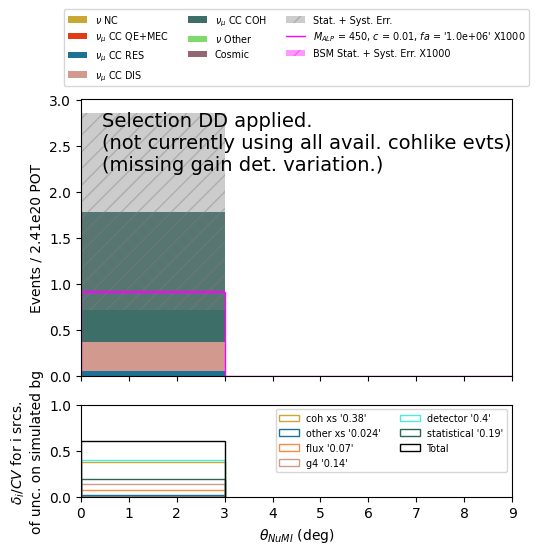

Total number of (POT-normalized) simulated background events in plot: '1.78'
Total uncertainty on simulated background events in plot: ±'1.07'
Total number of (POT-normalized) simulated signal events in plot: '0.00091'
Total uncertainty on simulated signal events in plot: ±'1.55e-05'


In [25]:
# October 31, 2025: to test updates
# same as cell below

# Theta NuMI with Benchmarked Event Selection

#mccoh_syst_evtdfs=[0]
mccoh_syst_evtdfs = mccoh_detVar_evtdfs
mccoh_dv_vars = [df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for df in mccoh_detVar_evtdfs]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, mccoh_dv_vars,
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection DD applied. \n(not currently using all avail. cohlike evts) \n(missing gain det. variation.)',
         bsm_index=10,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 1000,
         evtSel_key='DD',
             do_detector_variations=True  
        )

In [42]:
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]

cut_results = apply_cuts(evtdf, cut_list, thresholds=thresholds, detailed_nu='int_type', detailed_bsm=True)
pot_df = cut_results[1]
mask = cut_results[-1]


VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings):  2
[0.54968005 0.04193852]
selected_evtdf.shape:  (20509, 830)


/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2991164/2682127637.py:52: RuntimeWarning: invalid value encountered in divide
  cut_r

len(unq):  1


/tmp/ipykernel_2991164/1950435431.py:215: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_2991164/1950435431.py:338: RuntimeWarning: invalid value encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_2991164/1950435431.py:349: RuntimeWarning: invalid value encountered in divide
  p1.bar(bin_centers, mc_err/mc,
/tmp/ipykernel_2991164/1950435431.py:354: RuntimeWarning: invalid value encountered in divide
  print('Total percent uncertainty: \n', mc_err/mc)
/tmp/ipykernel_2991164/1950435431.py:383: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_2991164/1950435431.py:389: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


Total percent uncertainty: 
 [0.64448027        nan        nan]


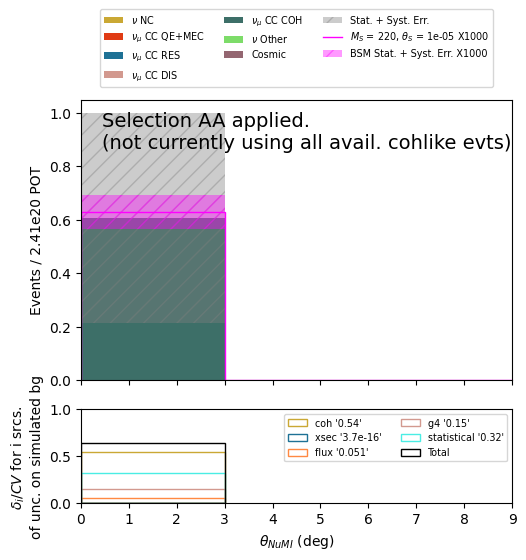

Total number of (POT-normalized) simulated background events in plot: '0.606'
Total uncertainty on simulated background events in plot: ±'0.391'
Total number of (POT-normalized) simulated signal events in plot: '0.000628'
Total uncertainty on simulated signal events in plot: ±'6.3e-05'


In [16]:
# Theta NuMI with Benchmarked Event Selection

mccoh_syst_evtdfs=[0]

#bsm_detector_varis_vars = []
#for bsm_sample in bsm_detector_varis_dfs:
#    this_samples_vars = []
#    for detect_variation_df in bsm_sample:
#        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
#    bsm_detector_varis_vars.append(this_samples_vars)
        
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi, #evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [0], #[sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection AA applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=0, #bsm_detector_varis_vars,
         bsm_magnifier = 1000,
         evtSel_key='AA',
             do_detector_variations=False
        )

In [36]:
## Assume 20% detector uncertainty (same as Gray):

tot_AA = 1/np.sqrt(0.54**2 + 0.082**2 + 0.15**2 + 0.32**2)
print(tot_AA)


1.537145069027188


In [19]:
#print('Number of ALP events required for sensitivity for Selection AA, assuming unc_signal=30% and...')
limit_dir = '/exp/icarus/data/users/jdyer/muons_selections_study_2511/wCVwgts/'

print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_AA60 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
#print(exp_limits_AA)
#print(exp_limits_AA*11.)
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_AA75 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_AA100 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)


#print('Number of ALP events required for sensitivity for Selection DD, assuming unc_signal=30% and...')
print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_DD60 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_DD75 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_DD100 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)

print('The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.')
print('The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.') 
#      our number of selected simulated background events.')


Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.10, 1.57, 2.66, 4.98, 9.68]
unc_bg=75%:  [1.10, 1.61, 2.71, 5.07, 9.80]
unc_bg=100%:  [1.12, 1.68, 2.83, 5.23, 10.04]
Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.65, 2.44, 3.89, 6.88, 12.68]
unc_bg=75%:  [1.78, 2.57, 4.07, 7.09, 12.98]
unc_bg=100%:  [1.98, 2.75, 4.32, 7.44, 13.45]
The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.
The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.


/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_671138/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_671138/3690885382.py:199: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)


Combined result minus separate result: 
 [            nan  6.24967734e-06 -7.33915330e-04 -2.82402115e-03
  6.50562600e-05  3.58516356e-02  2.30864988e-03  3.02486701e-04
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan             nan             nan             nan
             nan]


/tmp/ipykernel_671138/3690885382.py:330: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_671138/3690885382.py:336: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


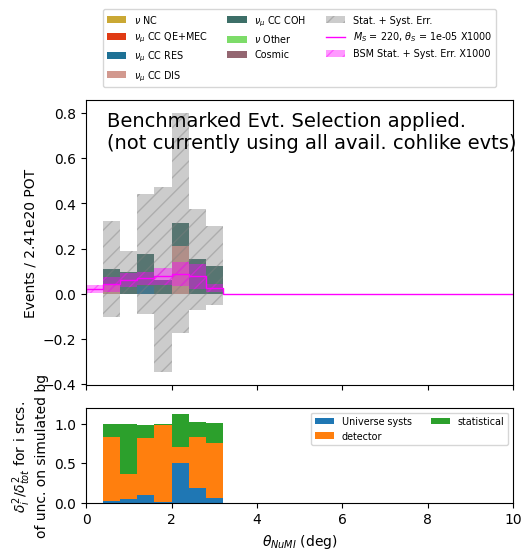

Total number of (POT-normalized) simulated background events in plot: '1.03'
Total uncertainty on simulated background events in plot: ±'0.781'
Total number of (POT-normalized) simulated signal events in plot: '0.00046'
Total uncertainty on simulated signal events in plot: ±'0.000104'


In [17]:
# Theta NuMI with Benchmarked Event Selection

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
x = makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Benchmarked Evt. Selection applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 1000,
         evtSel_key='I'
        )

In [28]:
for c in make_categories(evtdf, detailed_bsm=True):
    print(c.name)

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 340, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic


VERIFY THAT THIS NUMBER IS THREE (2 cohlike samples + 1 nominal sample, for three different POT scalings):  3
[0.54968005 0.08116821 0.08677293]


/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1071966/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  3
Total percent uncertainty: 
 [0.49647483 0.41869719 0.40873511 0.39708397 0.42547573 0.46616929
 0.52663853 0.78022757 1.14713454 0.71486856]


/tmp/ipykernel_1071966/3974722259.py:382: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv.tot,
/tmp/ipykernel_1071966/3974722259.py:388: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


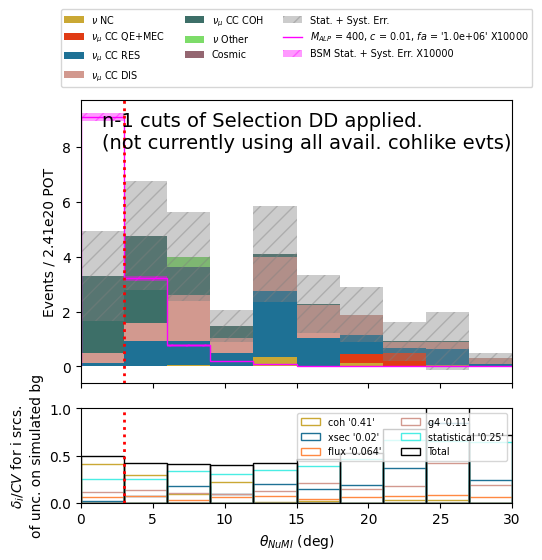

Total number of (POT-normalized) simulated background events in plot: '24'
Total uncertainty on simulated background events in plot: ±'4.07'
Total number of (POT-normalized) simulated signal events in plot: '0.00134'
Total uncertainty on simulated signal events in plot: ±'1.88e-05'


In [32]:
# Explore Sideband Defined as Flipped theta_NuMI

mccoh_syst_evtdfs=[0]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, [0],
         (0,30.), bins=10, vline=[3.],
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=10,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 10000,
         evtSel_key='J',
             do_detector_variations=False  
        )

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


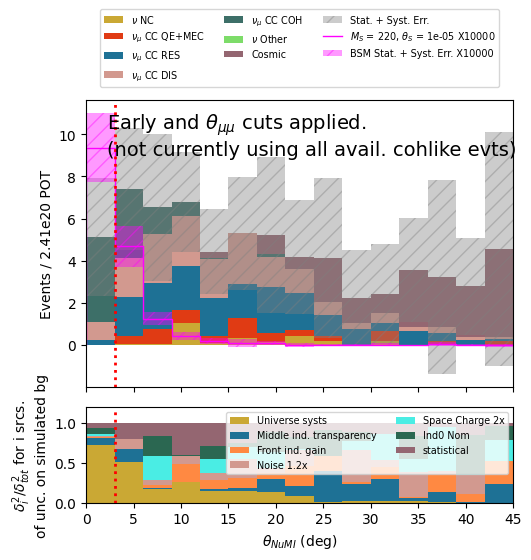

Total number of (POT-normalized) simulated background events in plot: '67.9'
Total uncertainty on simulated background events in plot: ±'46'
Total number of (POT-normalized) simulated signal events in plot: '0.00163'
Total uncertainty on simulated signal events in plot: ±'0.000395'


In [45]:
# Explore Sideband Defined as Flipped theta_NuMI

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,45.), bins=15, vline=[3.], xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Early and $\\theta_{\mu\mu}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='J'
        )

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


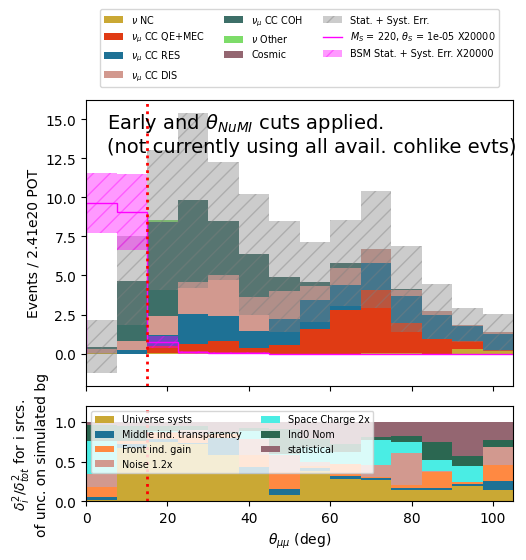

Total number of (POT-normalized) simulated background events in plot: '70.3'
Total uncertainty on simulated background events in plot: ±'41.7'
Total number of (POT-normalized) simulated signal events in plot: '0.00098'
Total uncertainty on simulated signal events in plot: ±'0.00025'


In [44]:
# Explore Sideband Defined as Flipped theta_mumu

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.opening_angle*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.opening_angle*180./math.pi,
         mccoh_syst_evtdfs, [sdf.opening_angle*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,105.), bins=14, vline=[15.], xlabel = "$\\theta_{\mu\mu}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_mumu',
         textOnPlot = 'Early and $\\theta_{NuMI}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 20000,
         evtSel_key='K'
        )


/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:160: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


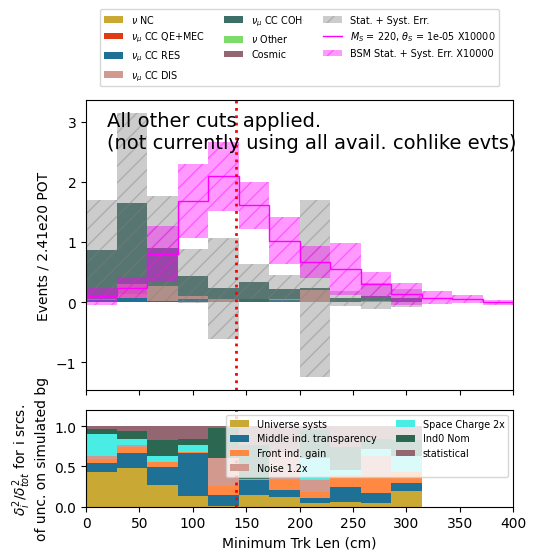

Total number of (POT-normalized) simulated background events in plot: '5.11'
Total uncertainty on simulated background events in plot: ±'6.96'
Total number of (POT-normalized) simulated signal events in plot: '0.000934'
Total uncertainty on simulated signal events in plot: ±'0.000403'


In [52]:
# Explore Sideband wrt Track Length

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.shorter_track_length)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.shorter_track_length,
         mccoh_syst_evtdfs, [sdf.shorter_track_length for sdf in mccoh_syst_evtdfs],
         (0,400.), bins=14, vline=[140.0], xlabel = "Minimum Trk Len (cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='trkLen',
         textOnPlot = 'All other cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='L'
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
running sum:
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
[0.00934477 0.04964293 0.02496197 0.0448164  0.03448711 0.0116307
 0.01161154 0.03940166 0.03179028 0.01441734 0.07084711 0.03851696
 0.08997049 0.056914   0.09368903 0.05640642 0.15994491 0.18646117
 0.07195568 0.27802487 0.35141691 0.24085815 0.18425634 0.21809734
 0.31742622]
running sum:
[0.50111331 0.85720344 0.7690

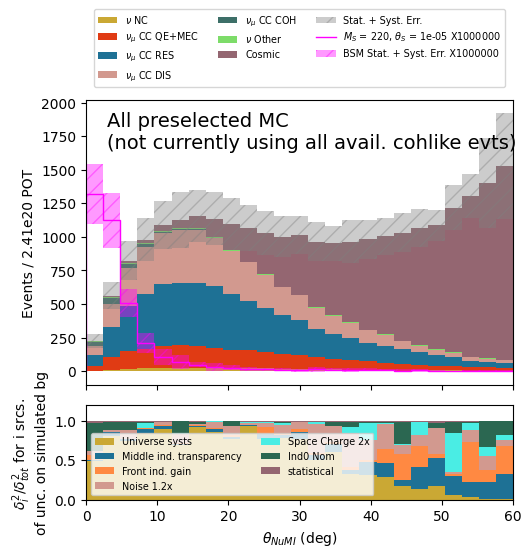

Total number of (POT-normalized) simulated background events in plot: '2.58e+04'
Total uncertainty on simulated background events in plot: ±'4.23e+03'
Total number of (POT-normalized) simulated signal events in plot: '0.00356'
Total uncertainty on simulated signal events in plot: ±'0.000935'


In [66]:
bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 1000000
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


UnboundLocalError: local variable 'middle_ind_cov' referenced before assignment

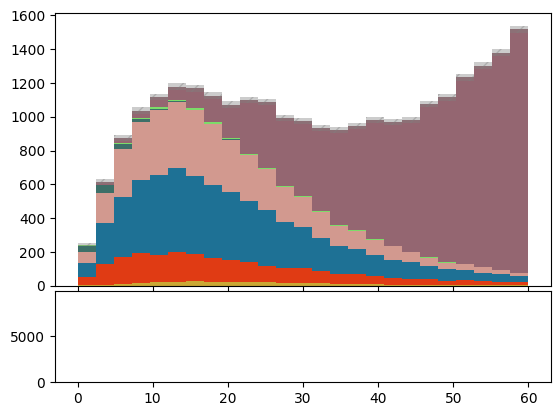

In [22]:
makeplot(evtdf, evtdf.Snumi_angle_mcs*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_mcs*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "MCS $\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI', 
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
        do_systs=False)

In [ ]:
# TODO: bottom panel: show uncert. squared (then I can show breakdown of contributing types.)
# To get model systematics: 

# what's my goal? Make a plot that shows:
# DONE - neutrinos, stacked by type, with total uncertainty
# - bsm benchmark(s) that are given (single or a list), plotted as line hist, with total uncertainty
# - (to be added later: ) data as data points, with statistical error
# - bottom panel shows breakdown of fractional uncertainty for each type of uncertainty, in each bin, as stacked hist.

# plot inputs:
# - nu_evtdf (concatenated from nominal nu df and cohlike dfs)
# - cohlike_evtdfs
# - bsm_df (one df per benchmark mass you want to plot)
# - list of sets (list of lists) of bsm detector variations 

In [44]:
print(len(soladero))

7


In [ ]:
# ma_300_syst_evtdfs, ma_300_syst_hdrs = extract_detVar_dfs("ma_300")

In [25]:
for df in ma_300_syst_evtdfs: 
    print(df.shape)
df = ma_300_syst_evtdfs[0]
for c in df.columns: print(c)
#plt.hist(df.Snumi_angle_wgtByLen*180/math.pi, 20)
#plt.show()

(165, 798)
(149, 798)
(172, 798)
(150, 798)
(165, 798)
(161, 798)
(145, 798)
('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('slc', 'truth', 'iscc', '', '', '')

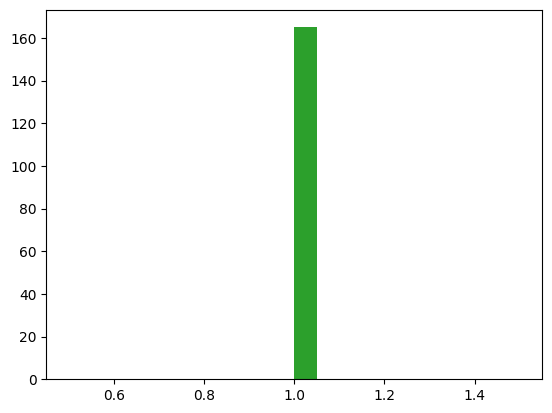

In [27]:
plt.hist(df.wgt.cv, 20)
plt.hist(df.wgt.concrete.cv, 20)
plt.hist(df.wgt.coh.cv, 20)
plt.show()